In [143]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch

In [144]:
from itertools import product

# Define action columns
action_columns = ['Medication', 'Therapy', 'Counseling']

# Generate all possible one-hot combinations
one_hot_combinations = list(product([0, 1], repeat=len(action_columns)))

# Create a mapping with meaningful labels
actions_dict = {}

for key, value in enumerate(one_hot_combinations):
    # Find active treatments
    active_treatments = [name for name, is_active in zip(action_columns, value) if is_active]
    
    # Create label
    if not active_treatments:
        label = "No Treatment"
    elif len(active_treatments) == 3:
        label = "All Treatments"
    else:
        label = " & ".join(active_treatments)

    actions_dict[label] = list(value)

# Display the updated dictionary
actions_dict


{'No Treatment': [0, 0, 0],
 'Counseling': [0, 0, 1],
 'Therapy': [0, 1, 0],
 'Therapy & Counseling': [0, 1, 1],
 'Medication': [1, 0, 0],
 'Medication & Counseling': [1, 0, 1],
 'Medication & Therapy': [1, 1, 0],
 'All Treatments': [1, 1, 1]}

In [145]:
atten_1 ={}
atten_2 = {}    
sampled_q_log_1 = {}
uncertainty_log_1 = {}



uncertainty_log_2 = {}
sampled_action_log_2 = {}
sampled_q_penality_log_2 = {}
sampled_q_normalized_log_2 = {}
sampled_q_values_log_2 = {}
reward_log_2 = {}
loss_1 = {}
loss_2 = {}
for i in range (1,11):
    try:
        # atten_1[i]=pd.read_hdf (f"attention_results/attention_log_level_1_{i}.h5")
        # sampled_q_log_1[i] = pd.read_hdf(f"attention_results/sample_q_log_level_1_{i}.h5")
        # uncertainty_log_1[i] = pd.read_hdf(f"attention_results/uncertainty_log_level_1_{i}.h5")

        atten_2[i]=pd.read_hdf (f"attention_results/attention_log_level_2_{i}.h5")
        # sampled_action_log_2[i] = pd.read_hdf(f"attention_results/sample_action_log_level_2_{i}.h5")

        # sampled_q_penality_log_2[i] = pd.read_hdf(f"attention_results/sample_q_penaltiy_log_level_2_{i}.h5")
        # sampled_q_penality_log_2 = torch.Tensor(sampled_q_penality_log_2.values)
        # sampled_q_penality_log_2 = pd.DataFrame(torch.exp(sampled_q_penality_log_2)/torch.exp(sampled_q_penality_log_2).sum(1).unsqueeze(1))
        # normlize the sampled_q_penality_log_2 between 0 and 1
        # sampled_q_penality_log_2[i] = (sampled_q_penality_log_2[i] - sampled_q_penality_log_2[i].min()) / (sampled_q_penality_log_2[i].max() - sampled_q_penality_log_2[i].min())
        sampled_q_normalized_log_2[i] = pd.read_hdf(f"attention_results/sample_q_normalized_log_level_2_{i}.h5")
        # sampled_q_normalized_log_2[i] = torch.Tensor(sampled_q_normalized_log_2[i].values)
        # sampled_q_normalized_log_2[i] = pd.DataFrame(torch.exp(sampled_q_normalized_log_2[i])/torch.exp(sampled_q_normalized_log_2[i]).sum(1).unsqueeze(1))
        # sampled_q_normalized_log_2[i] = (sampled_q_normalized_log_2[i] - sampled_q_normalized_log_2[i].min()) / (sampled_q_normalized_log_2[i].max() - sampled_q_normalized_log_2[i].min())

        # sampled_q_target_log_2 = pd.read_hdf("attention_results/sample_q_target_log_level_2.h5")
        # sampled_q_values_log_2[i] = pd.read_hdf(f"attention_results/sample_q_values_log_level_2_{i}.h5")
        uncertainty_log_2[i] = pd.read_hdf(f"attention_results/uncertainty_log_level_2_{i}.h5")
        reward_log_2[i] = pd.read_hdf(f"attention_results/selected_rewards_{i}.h5")
        
        
        # sampled_q_log_1[i]=sampled_q_log_1[i].T
        # sampled_action_log_2[i]=sampled_action_log_2[i].T
        # sampled_q_penality_log_2[i]=sampled_q_penality_log_2[i].T
        sampled_q_normalized_log_2[i]= sampled_q_normalized_log_2[i].T
        # sampled_q_values_log_2[i]=sampled_q_values_log_2[i].T

        # uncertainty_log_1[i].columns = ['Uncertainty']
        uncertainty_log_2[i].columns = ['Uncertainty']
        reward_log_2[i].columns = ['Reward']


        # sampled_q_log_1[i] = pd.concat([sampled_q_log_1[i], uncertainty_log_1[i]], axis=1)
        # sampled_action_log_2[i] = pd.concat([sampled_action_log_2[i], uncertainty_log_2[i]], axis=1)
        # sampled_q_penality_log_2[i] = pd.concat([sampled_q_penality_log_2[i], uncertainty_log_2[i]], axis=1)
        sampled_q_normalized_log_2[i] = pd.concat([sampled_q_normalized_log_2[i], uncertainty_log_2[i] , reward_log_2[i]], axis=1)
        # sampled_q_values_log_2[i] = pd.concat([sampled_q_values_log_2[i], uncertainty_log_2[i]], axis=1)


        # loss_1[i] = pd.read_hdf(f"attention_results/loss_log_level_1_{i}.h5")
        loss_2[i] = pd.read_hdf(f"attention_results/loss_log_level_2_{i}.h5")
    except:
        pass

In [146]:
sampled_q_normalized_log_2

{1:             0         1         2         3         4         5         6  \
 0   -0.642899 -1.286262  0.981051  1.149113  0.741742  0.836748 -1.032009   
 1   -0.576312 -1.276416  1.020225  1.089998  0.812711  0.849592 -1.127690   
 2   -0.664294 -1.231114  1.039455  1.125728  0.761273  0.810400 -1.107298   
 3   -0.612352 -1.318333  1.058072  1.041817  0.800306  0.845820 -1.048714   
 4   -0.608414 -1.295435  0.996579  1.003492  0.952075  0.831049 -1.072266   
 ..        ...       ...       ...       ...       ...       ...       ...   
 496 -0.420064 -1.257279  0.723843  1.010702  1.255507  0.764903 -1.236253   
 497 -0.458653 -1.251535  0.710284  0.999755  1.248083  0.829457 -1.262802   
 498 -0.443717 -1.260060  0.727461  1.039961  1.215780  0.772906 -1.224423   
 499 -0.484785 -1.292299  0.678880  1.038146  1.252239  0.805398 -1.253115   
 500 -0.418611 -1.252316  0.671685  1.014248  1.250229  0.796411 -1.231534   
 
             7  Uncertainty    Reward  
 0   -0.747483     

In [147]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_loss(loss_df_dicts):
    """
    Plots multiple loss DataFrames stored in a dictionary.
    Each DataFrame is plotted in a subplot, arranged dynamically based on the number of entries.
    
    Args:
        loss_df_dicts (dict): Dictionary where keys are loss names and values are DataFrames with loss columns.
    """
    num_plots = len(loss_df_dicts)
    
    # Determine subplot grid size (adjust dynamically)
    num_cols = min(2, num_plots)  # Max 5 columns per row
    num_rows = (num_plots // num_cols) + (num_plots % num_cols > 0)  # Dynamic row calculation

    # Create subplots
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6 * num_rows))
    axes = np.array(axes).flatten()  # Flatten in case of 1D array
    
    window_size = 1  # Moving average window
    
    for i, (loss_name, loss_df) in enumerate(loss_df_dicts.items()):
        if not isinstance(loss_df, pd.DataFrame):
            continue  # Skip if it's not a DataFrame

        # Apply moving average smoothing
        smoothed_loss_df = loss_df.rolling(window=window_size, min_periods=1).mean()

        # Plot each loss column
        ax = axes[i]
        for col in loss_df.columns:
            ax.plot(smoothed_loss_df.index, smoothed_loss_df[col], label=col, alpha=0.7)

        ax.set_xlabel("Time Steps")
        ax.set_ylabel("Loss Value")
        ax.set_title(f"Smoothed Losses: {loss_name}")
        ax.legend()

    # Remove any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Example Usage (assuming you have multiple loss DataFrames in a dictionary)
# loss_df_dicts = {"Level 1": df1, "Level 2": df2, "Critic Loss": df3, ...}
# plot_loss(loss_df_dicts)


In [184]:
def plot_sampled_q_values_with_softmax(sampled_q_log_dict, actions_dict):
    num_plots = len(sampled_q_log_dict)
    print(num_plots)
    num_cols = min(2, num_plots)  # Max 2 columns per row
    num_rows = (num_plots // num_cols) + (num_plots % num_cols > 0)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6 * num_rows))
    axes = np.array(axes).flatten()  # Flatten in case of 1D array

    for i, (log_name, log_df) in enumerate(sampled_q_log_dict.items()):
        ax = axes[i]

        # Ensure DataFrame is valid
        if log_df is None or log_df.empty:
            ax.set_title(f"{log_name} (No Data)")
            ax.axis("off")
            continue

        # Extract time steps
        time_steps = log_df.index.to_numpy()

        # Extract Q-values, uncertainty, and reward
        q_values = log_df.iloc[:, :-2].values  # All columns except last two are Q-values
        uncertainty_values = np.exp(-log_df["Uncertainty"].values)  # Convert uncertainty
        reward_values = log_df["Reward"].values  # Extract reward values

        # Scale Q-values for stability
        q_values_scaled = (q_values - q_values.min(axis=1, keepdims=True)) / (
            q_values.max(axis=1, keepdims=True) - q_values.min(axis=1, keepdims=True) + 1e-6
        )

        # Scale uncertainty values
        uncertainty_values = (uncertainty_values - uncertainty_values.min()) / (
            uncertainty_values.max() - uncertainty_values.min() + 1e-6
        )

        # Apply Softmax to Q-values
        softmax_q_values = F.softmax(torch.tensor(q_values), dim=1).numpy()

        # Colormap for different actions
        colors = plt.cm.get_cmap("tab10", q_values.shape[1])

        # Plot each action's Softmax probabilities separately with uncertainty
        for j in range(q_values.shape[1]):
            # Find the corresponding treatment name
            treatment_name = list(actions_dict.keys())[j]

            ax.plot(time_steps, softmax_q_values[:, j], marker="o", linestyle="-", markersize=3, alpha=0.7,
                    label=treatment_name, color=colors(j))

            # Compute uncertainty bounds
            lower_bound = q_values_scaled[:, j] - uncertainty_values
            upper_bound = q_values_scaled[:, j] + uncertainty_values

            # ax.fill_between(time_steps, lower_bound, upper_bound, color=colors(j), alpha=0.3)

        # Plot uncertainty and reward separately
        ax.plot(time_steps, uncertainty_values, label="Uncertainty", color="black", linestyle="--", linewidth=1, alpha=0.7)
        ax.plot(time_steps, reward_values, label="Reward", color="red", linestyle="--", linewidth=1, alpha=0.7)

        ax.set_xlabel("Time Steps")
        ax.set_ylabel("Softmax Probabilities & Uncertainty")
        ax.set_title(f"Softmax of Q-Values Over Time: {log_name}")
        ax.legend()
        ax.grid(True)

    # Remove unused axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    # fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9) , ncol=1)
    plt.show()

10


/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_19697/939949396.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", q_values.shape[1])


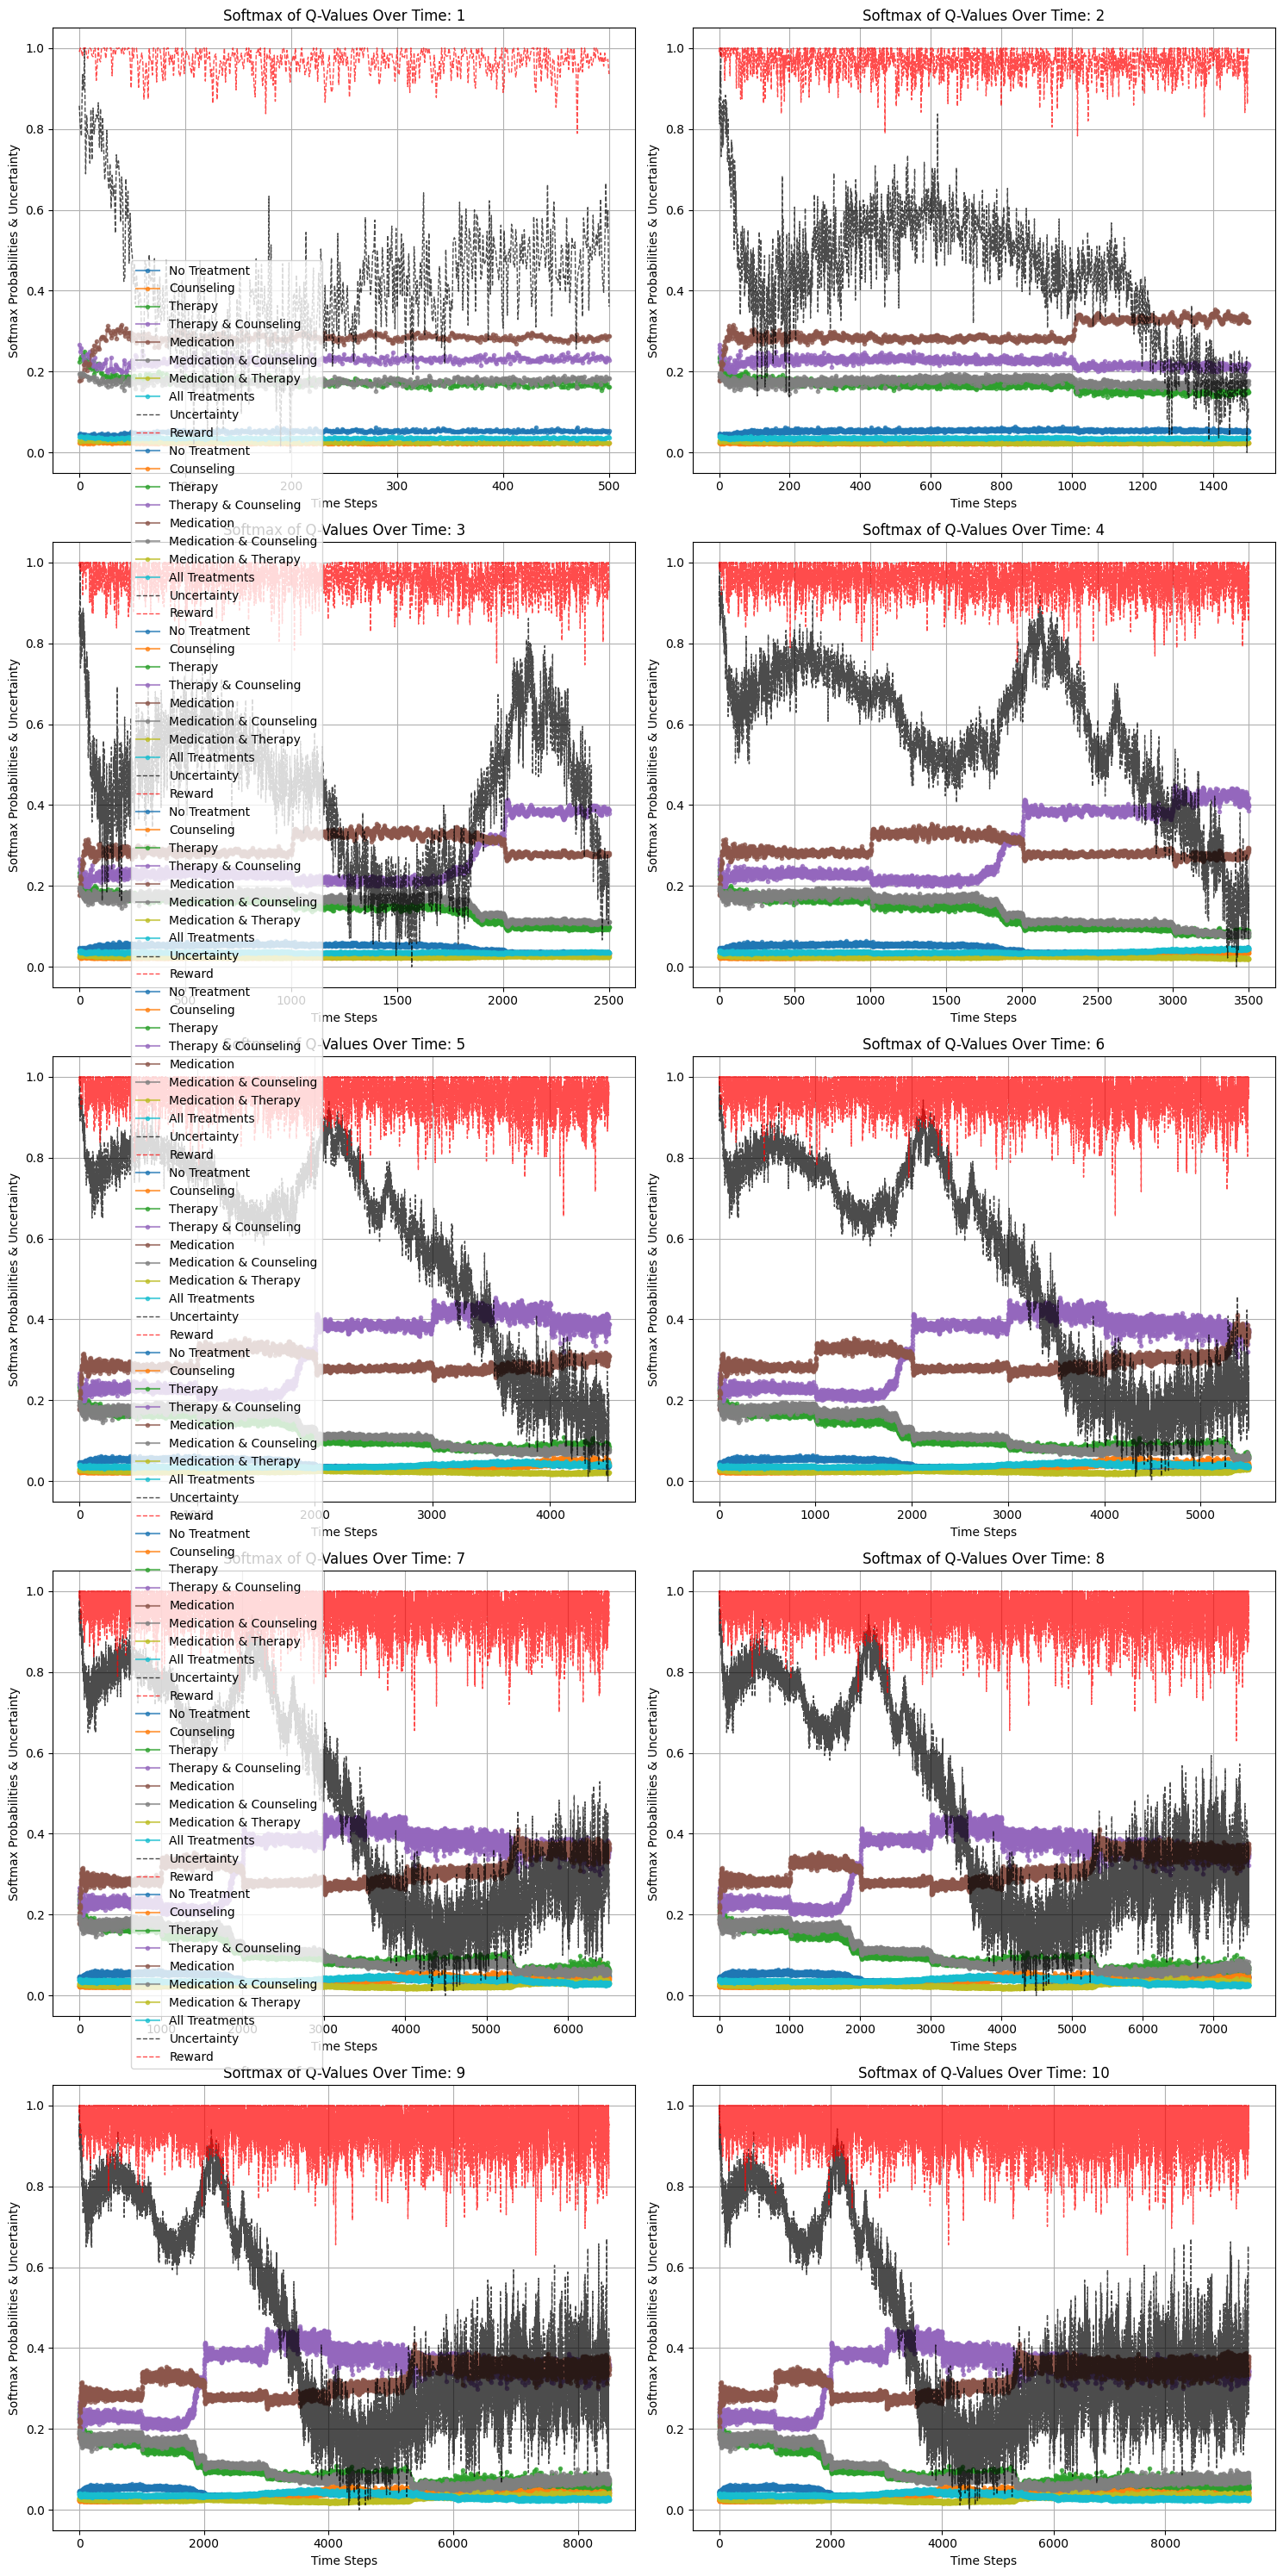

In [183]:
plot_sampled_q_values_with_softmax(sampled_q_normalized_log_2, actions_dict)

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_attention(atten_dics):
    """
    Plots multiple attention heatmaps stored in a dictionary.
    Each attention map is plotted in a subplot, arranged dynamically based on the number of entries.
    
    Args:
        atten_dics (dict): Dictionary where keys are attention names and values are attention matrices.
    """
    num_plots = len(atten_dics)
    

    # Determine subplot grid size (adjust dynamically)
    num_cols = min(2, num_plots)  # Max 5 columns per row
    num_rows = (num_plots // num_cols) + (num_plots % num_cols > 0)  # Dynamic row calculation

    # Create subplots
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 6 * num_rows))
    axes = np.array(axes).flatten()  # Flatten in case of 1D array

    for i, (attn_name, attn_data) in enumerate(atten_dics.items()):

        # if not isinstance(attn_data, np.ndarray):
        #     continue  # Skip if it's not a numpy array

        ax = axes[i]
     

        # Create heatmap
        sns.heatmap(attn_data, cmap="Blues", annot=False, linewidths=0, ax=ax)
        ax.set_xlabel("Time Steps")
        ax.set_ylabel("Feature Index")
        ax.set_title(f"Attention Heatmap: {attn_name}")

    # Remove any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Example Usage (assuming you have multiple attention maps in a dictionary)
# atten_dics = {"Layer 1": np.random.rand(50, 10), "Layer 2": np.random.rand(50, 10), ...}
# plot_attention(atten_dics)


In [111]:
# plot_attention(atten_1)
# plot_sampled_q_values_with_uncertainty(sampled_q_log_1)
# plot_sampled_q_values_with_uncertainty(sampled_action_log_2)
# plot_sampled_q_values_with_uncertainty(sampled_action_log_2)
# plot_sampled_q_values_with_uncertainty(sampled_q_penality_log_2)

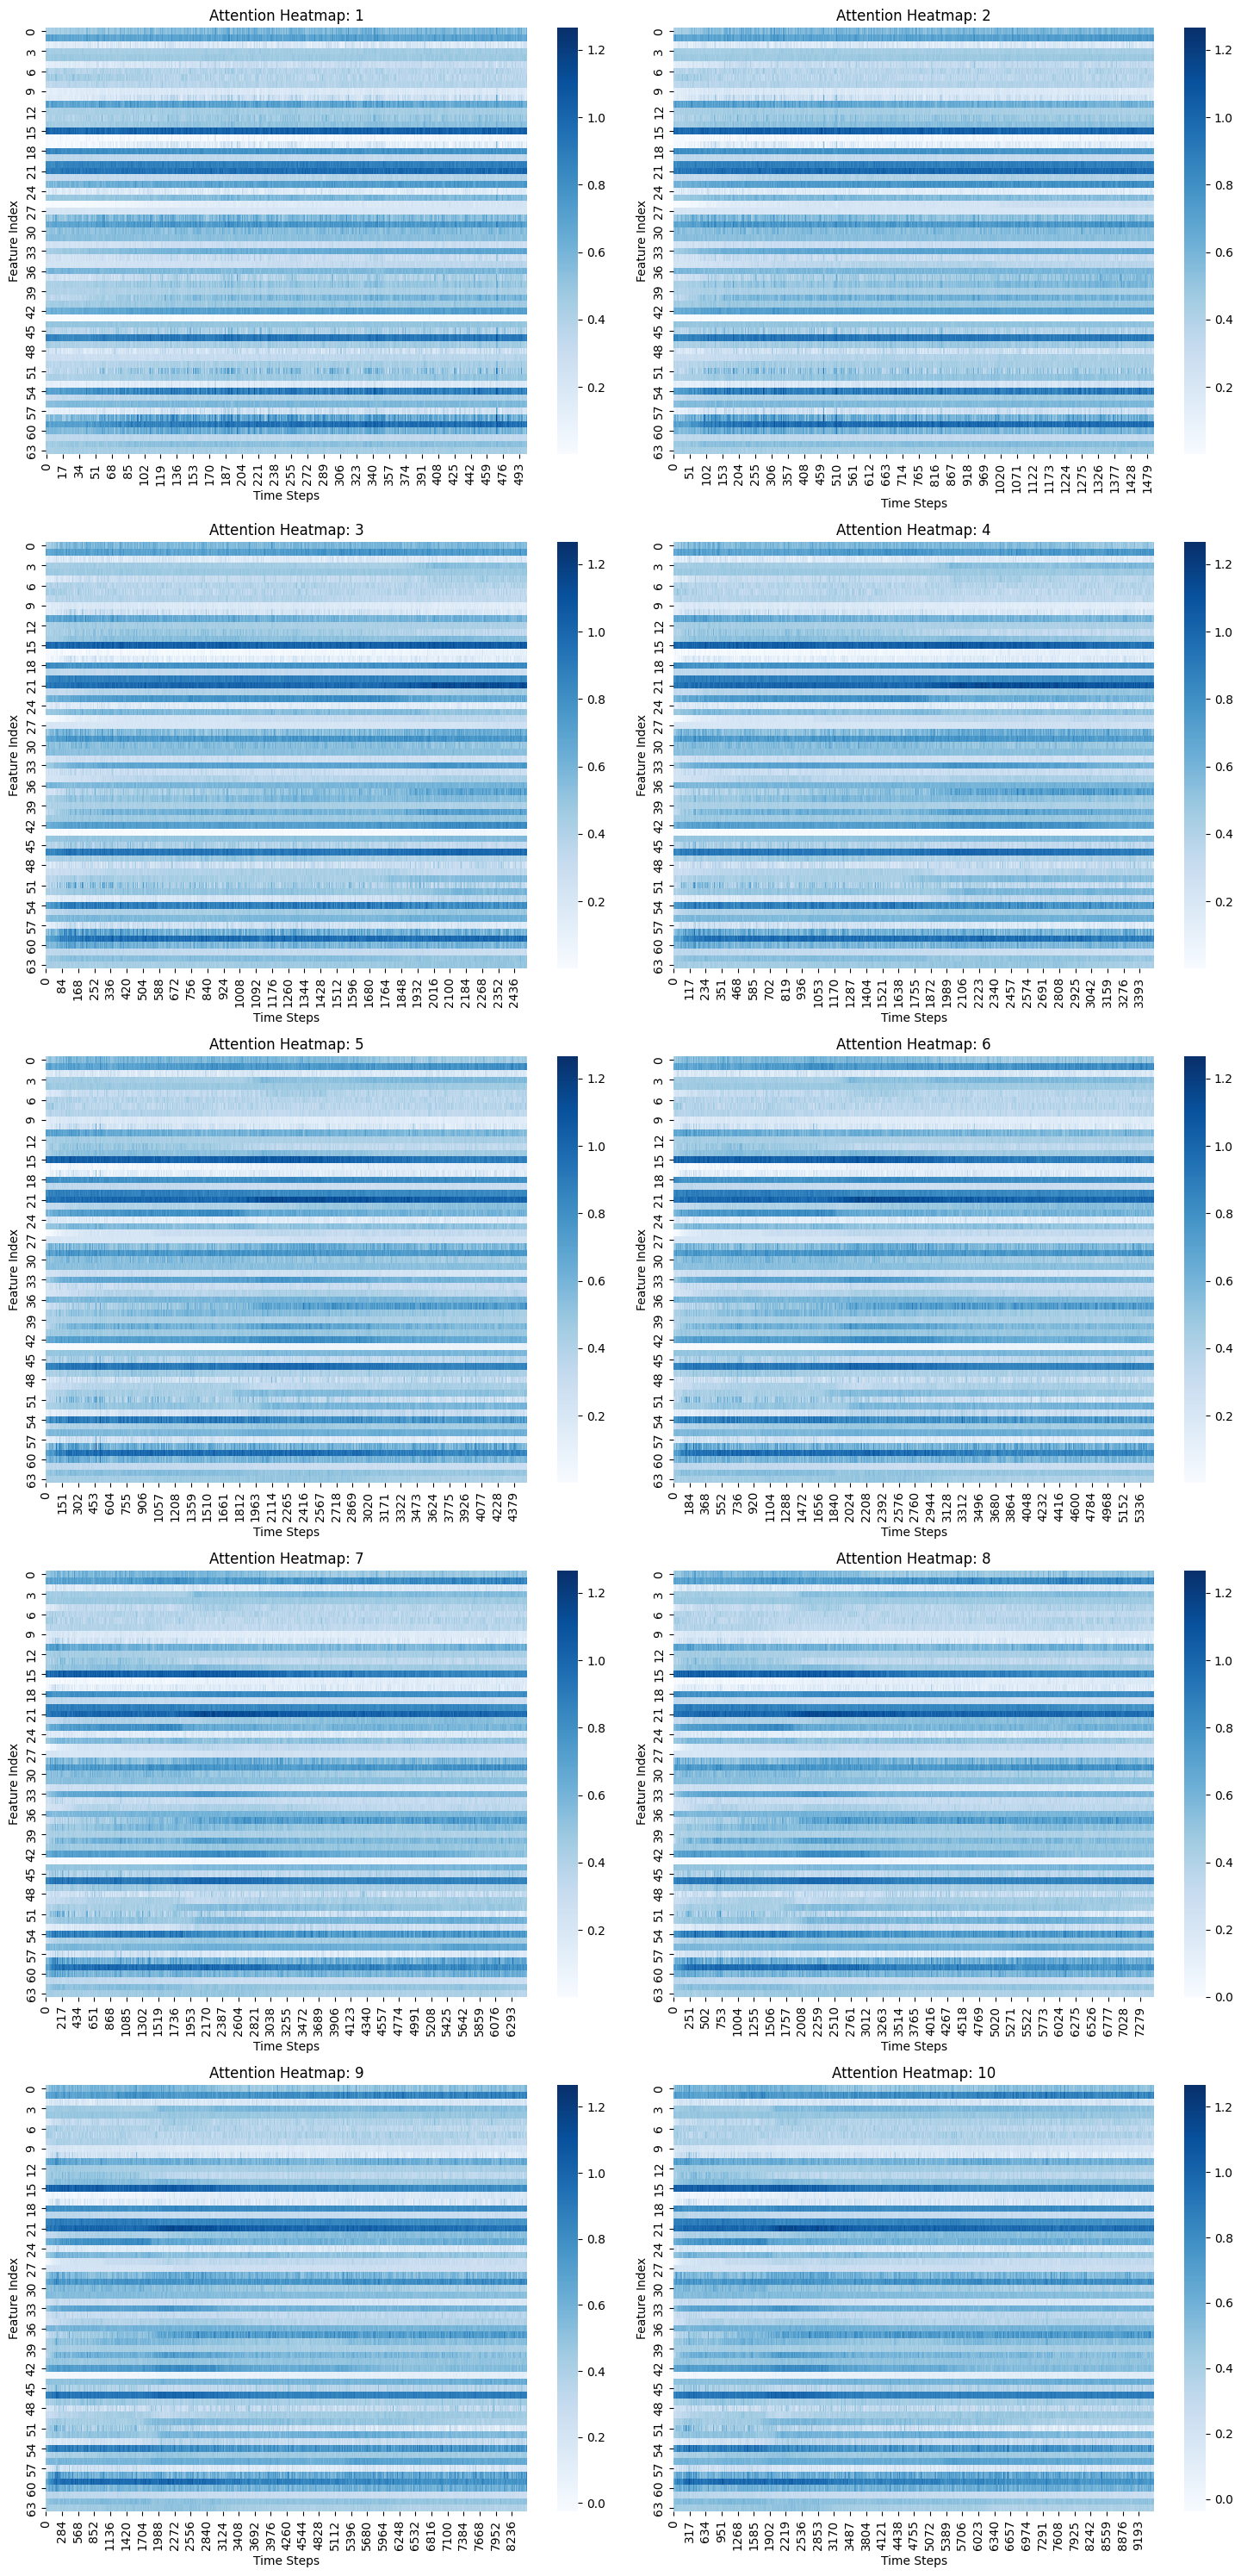

In [15]:
plot_attention(atten_2) 

/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_19697/4030084466.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", q_values.shape[1])


AttributeError: module 'numpy' has no attribute 'softmax'

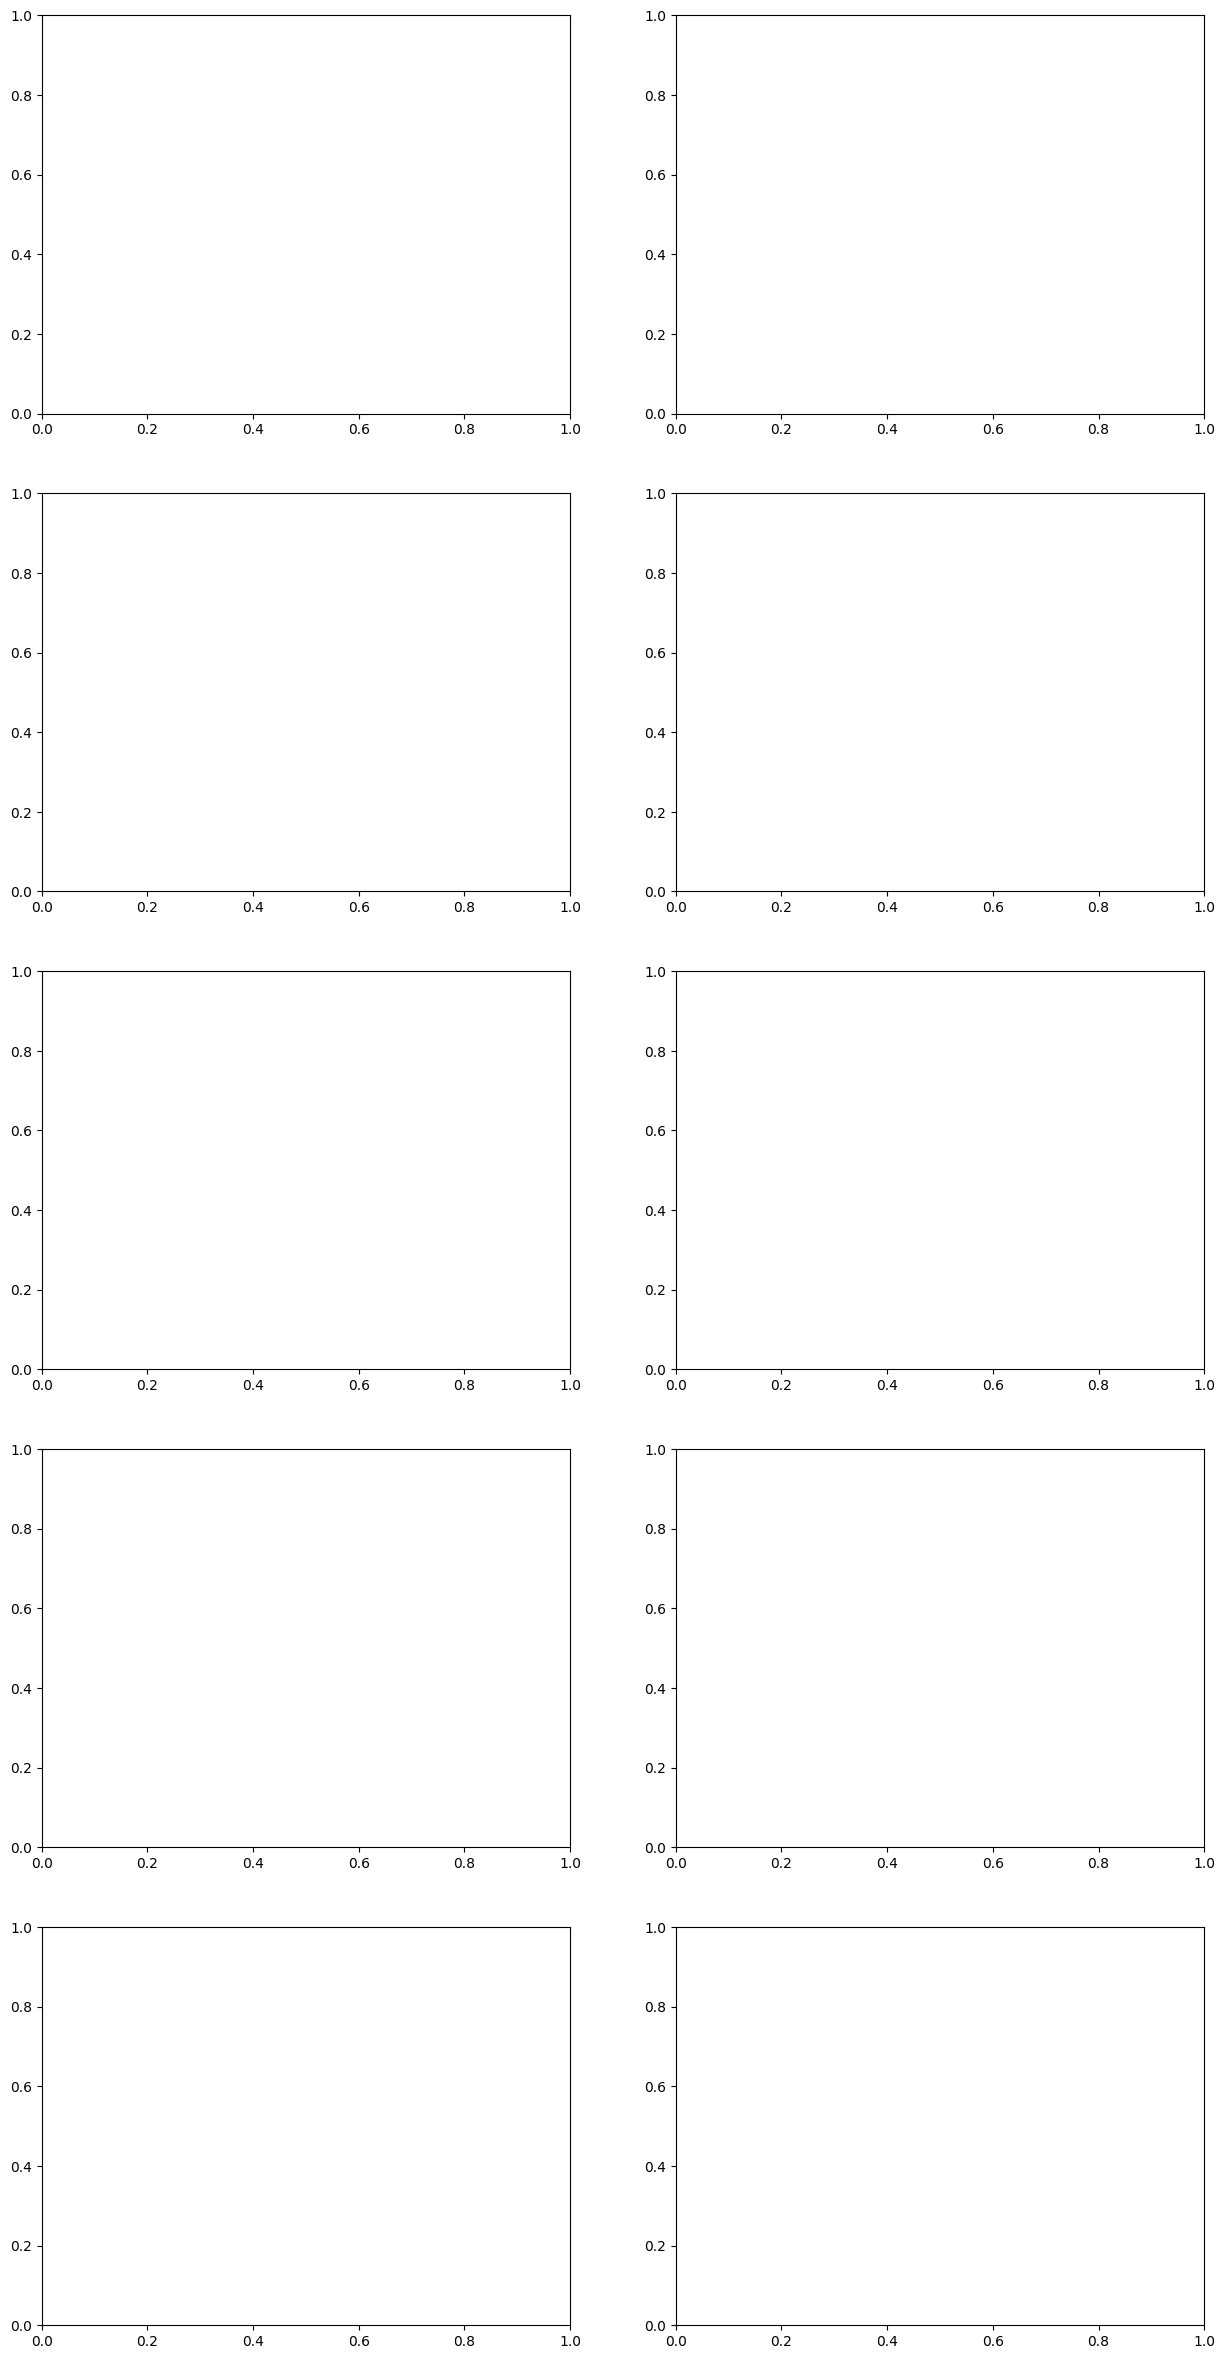

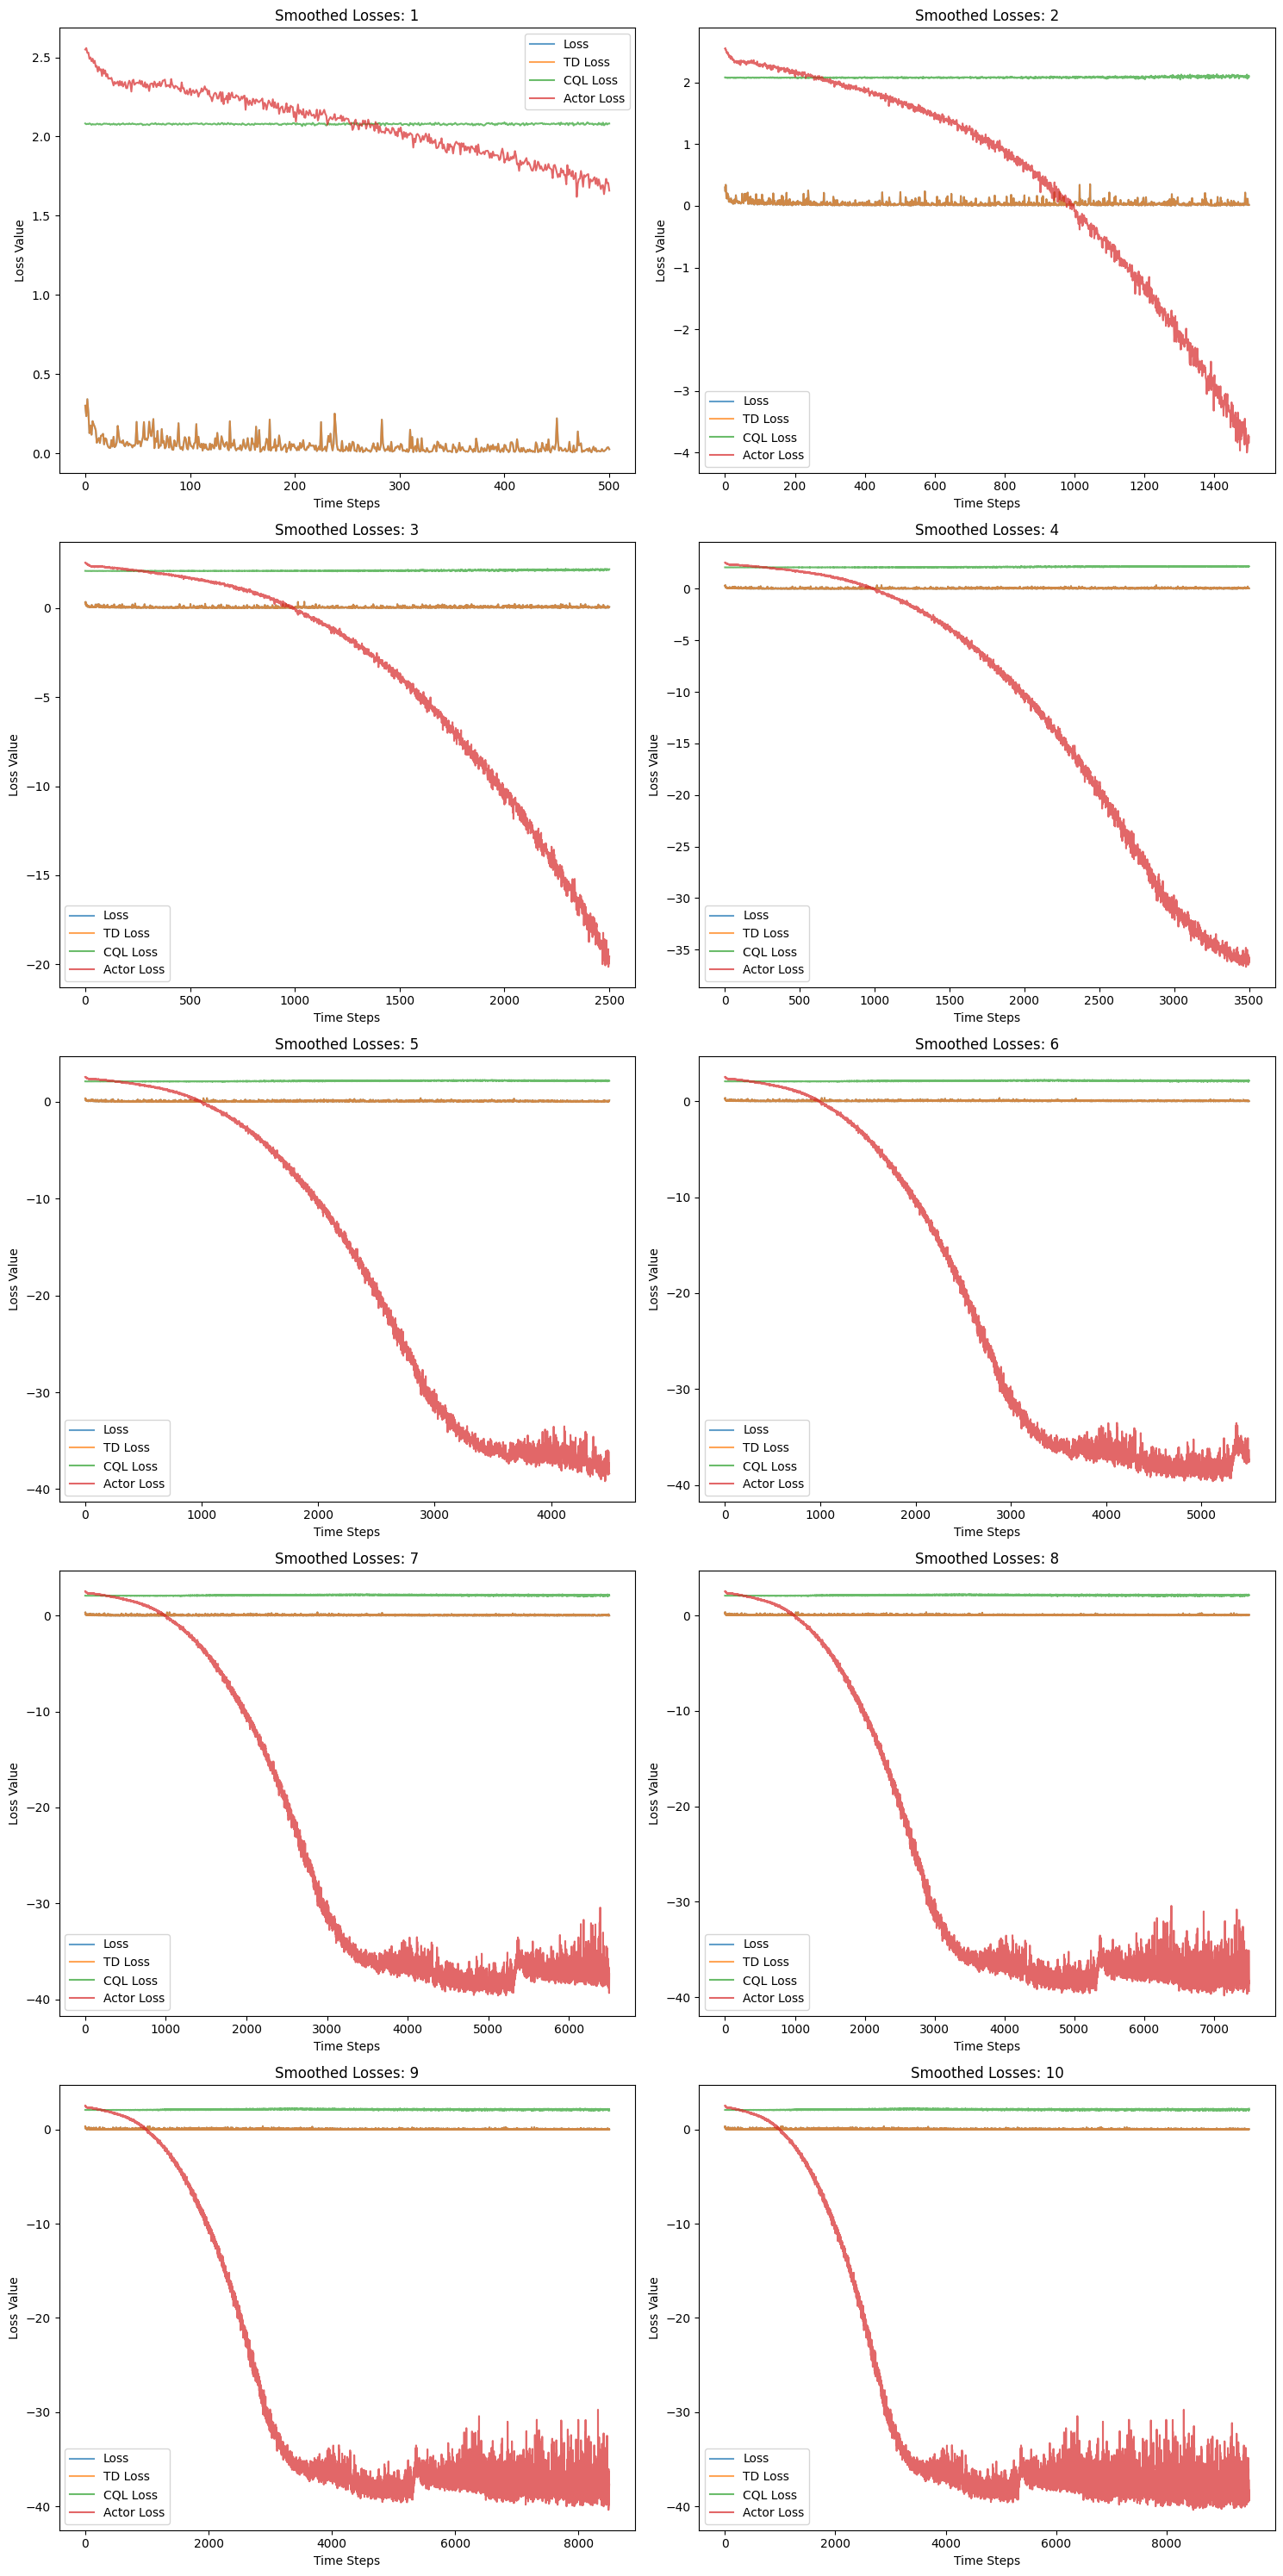

In [17]:
plot_loss(loss_2)

In [18]:
# import matplotlib.pyplot as plt
# import numpy as np
# import scipy.ndimage

# def smooth_curve(data, sigma=10):   
#     """Applies Gaussian smoothing to reduce noise."""
#     return scipy.ndimage.gaussian_filter1d(data, sigma=sigma)

# def plot_sampled_q_values_with_uncertainty_smooth(sampled_q_log):
#     """
#     Plots smooth sampled Q-values for each action (0-7) and overlays Action 8 as uncertainty.
#     """

#     plt.figure(figsize=(10, 6))
#     plt.clf()  # Clear previous plot

#     # 🔹 Ensure sampled_q_log is a NumPy array
#     if isinstance(sampled_q_log, dict):
#         actions = list(sampled_q_log.keys())  # Get action indices
#         sampled_q_array = np.array([sampled_q_log[action] for action in actions])
#     else:
#         sampled_q_array = np.array(sampled_q_log)  # Convert list of lists to NumPy array
#         actions = range(sampled_q_array.shape[0])  # Generate action numbers dynamically

#     time_steps = np.arange(sampled_q_array.shape[1])  # X-axis: Time steps

#     # 🔹 Separate sampled Q-values (actions 0-7) and uncertainty (action 8)
#     action_q_values = sampled_q_array[:-1, :]  # Actions 0-6
#     uncertainty_values = sampled_q_array[-1, :]  # Action 8 (Uncertainty)

#     colors = plt.cm.get_cmap("tab10", len(action_q_values))  # Use tab10 colormap for distinguishable colors

#     # 🔹 Plot each action's Q-values with smoothing
#     sigma = 100  # Smoothing factor
#     for i in range(len(action_q_values)):  # Only plot first 7 actions
    
#         smoothed_q_values = smooth_curve(action_q_values[i], sigma=sigma)  # Apply Gaussian smoothing
#         plt.plot(time_steps, smoothed_q_values,linestyle="-", linewidth=2, label=f"Action {i}", color=colors(i))

#     # 🔹 Overlay Action 8 as uncertainty (shaded region)
#     smoothed_mean_q = smooth_curve(action_q_values.mean(axis=0), sigma=sigma)
#     smoothed_uncertainty = smooth_curve(uncertainty_values, sigma=sigma)

#     plt.fill_between(time_steps, smoothed_mean_q - smoothed_uncertainty,
#                      smoothed_mean_q + smoothed_uncertainty, alpha=0.7, color="black",
#                      edgecolor="none", label="Uncertainty (± Std Dev)")

#     plt.xlabel("Time Steps")
#     plt.ylabel("Sampled Action probabilities - and Uncertainty")
#     plt.title("Smoothed Action probabilities Over Time with Uncertainty")
#     plt.legend()
#     plt.grid(True)
#     plt.show()


In [252]:
def plot_sample_q_actoin(sampled_q_log):
    fig, ax = plt.subplots(figsize=(10, 6))



    attn_array = np.array(sampled_q_log.T)  # Convert deque to numpy array
    # Create heatmap
    sns.heatmap(attn_array, cmap="Blues", annot=False, linewidths=0.0005, ax=ax)
    ax.set_xlabel("Time Steps")
    ax.set_ylabel("Feature Index")

    # sns.heatmap(sampled_q_log, cmap="Blues", annot=False, linewidths=0, ax=ax)
    # ax.set_xlabel("Time Steps")
    # ax.set_ylabel("Feature Index")
    # ax.set_title("Real-Time Feature Attention Heatmap")
    # plt.show()

AttributeError: 'dict' object has no attribute 'T'

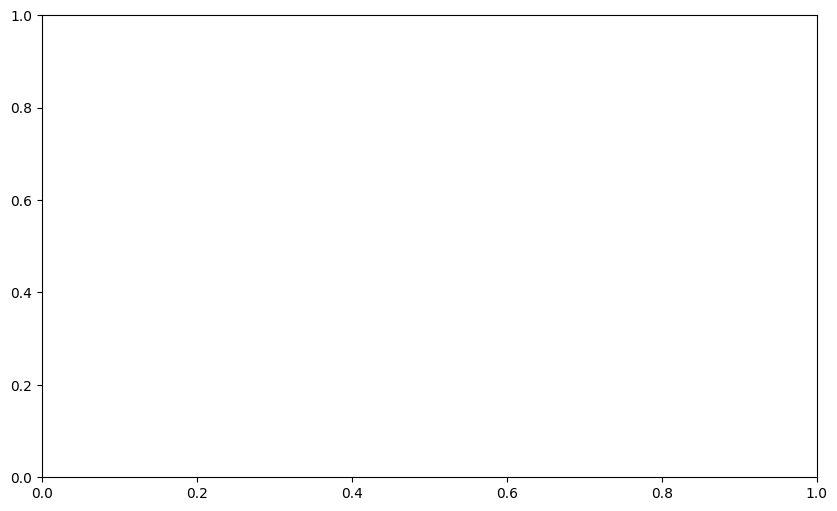

In [348]:
plot_sample_q_actoin(sampled_q_log_1)

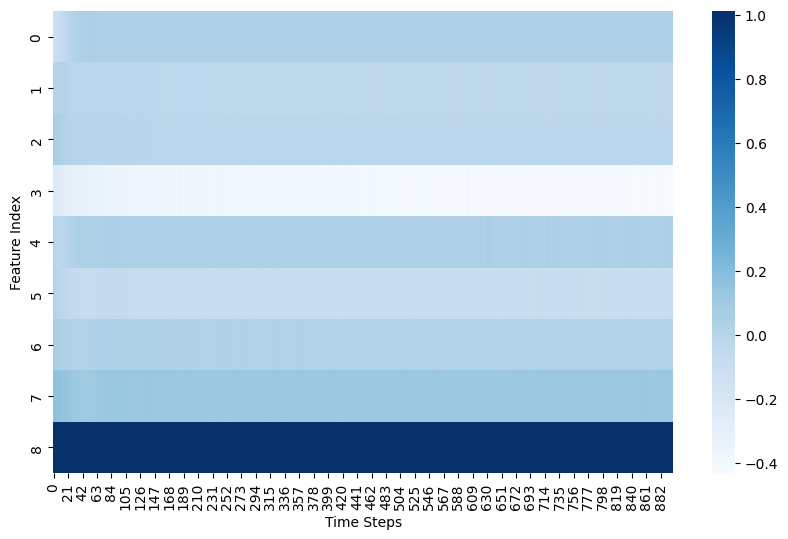

In [ ]:
plot_sample_q_actoin(sampled_q_values_log_2)

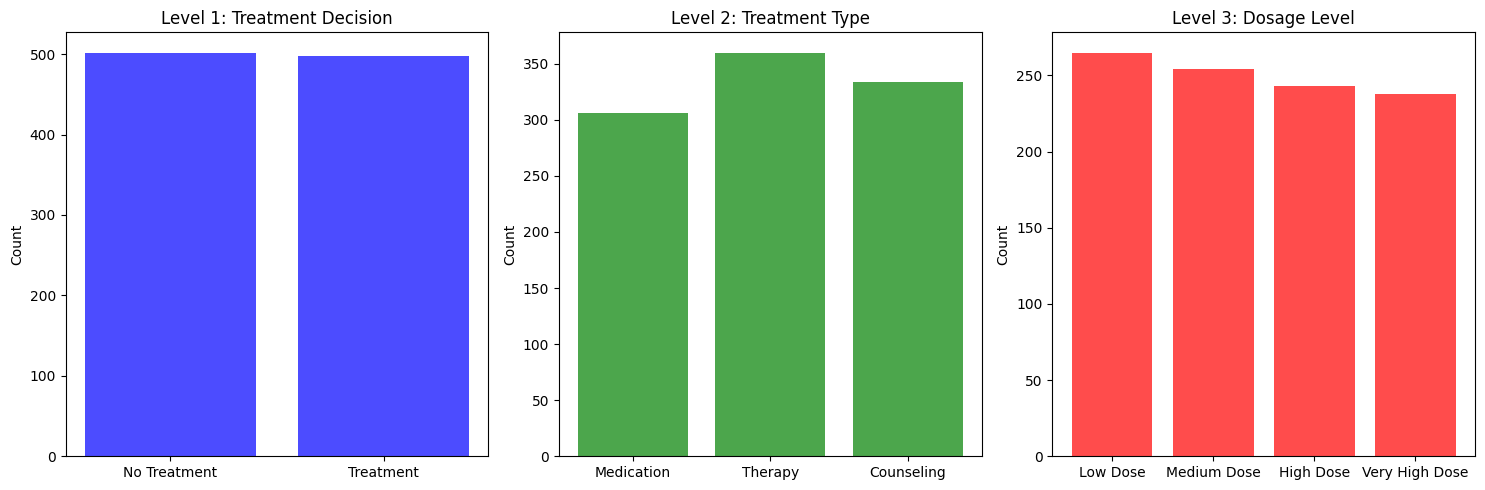

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example synthetic action dataset (Replace with real action logs)
actions_level_1 = np.random.choice([0, 1], size=1000)  # Treatment or No Treatment
actions_level_2 = np.random.choice(range(3), size=1000)  # 3 Treatment Types
actions_level_3 = np.random.choice(range(4), size=1000)  # 4 Dosage Levels

# Count occurrences for each level
level_1_counts = np.bincount(actions_level_1, minlength=2)
level_2_counts = np.bincount(actions_level_2, minlength=3)
level_3_counts = np.bincount(actions_level_3, minlength=4)

# Define Labels
level_1_labels = ["No Treatment", "Treatment"]
level_2_labels = ["Medication", "Therapy", "Counseling"]
level_3_labels = ["Low Dose", "Medium Dose", "High Dose", "Very High Dose"]

# Plot Action Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Level 1
axes[0].bar(level_1_labels, level_1_counts, color='blue', alpha=0.7)
axes[0].set_title("Level 1: Treatment Decision")
axes[0].set_ylabel("Count")

# Level 2
axes[1].bar(level_2_labels, level_2_counts, color='green', alpha=0.7)
axes[1].set_title("Level 2: Treatment Type")
axes[1].set_ylabel("Count")

# Level 3
axes[2].bar(level_3_labels, level_3_counts, color='red', alpha=0.7)
axes[2].set_title("Level 3: Dosage Level")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [355]:
import math
def example_func(file_size):
    block_size = 4096

    full_blocks = round(file_size / block_size)+1
    
    
    
    
    print (full_blocks)
    partial_block = file_size % block_size

    # if partial_block>0:
    #     return full_blocks + 1
    # return full_blocks

example_func(4096)

2


In [3447]:
[12                  4096] [4097          ]

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1135377301.py, line 1)

In [ ]:
file_size = 4097 # bytes
block_size = 4096 # bytes


# full_blocks= math.floor(file_size / block_size)+1

In [ ]:
partial_remainder = file_size % block_size
partial_remainder

1

In [ ]:
full_size = full_blocks * block_size

8192

In [ ]:
print ("hello")

hello


In [ ]:
print ("world")

world


In [ ]:
filesize = 8000
block_size = 4096


print(filesize % block_size)

3904


In [ ]:
filesize // block_size

1

In [3080]:
def calculate_storage(filesize):
    block_size = 4096
    full_blocks = filesize // block_size
    partial_remainder = filesize % block_size
    if partial_remainder>0:
        return (full_blocks + 1) * block_size
    return full_blocks * block_size
    

In [3081]:
print(calculate_storage(1))
print(calculate_storage(4096))
print(calculate_storage(4097))
print(calculate_storage(6000))

4096
4096
8192
8192


In [3082]:
full_blocks = 20//3
partail_block_remainder=20%3
if partail_block_remainder>0:
    full_blocks = full_blocks + 1

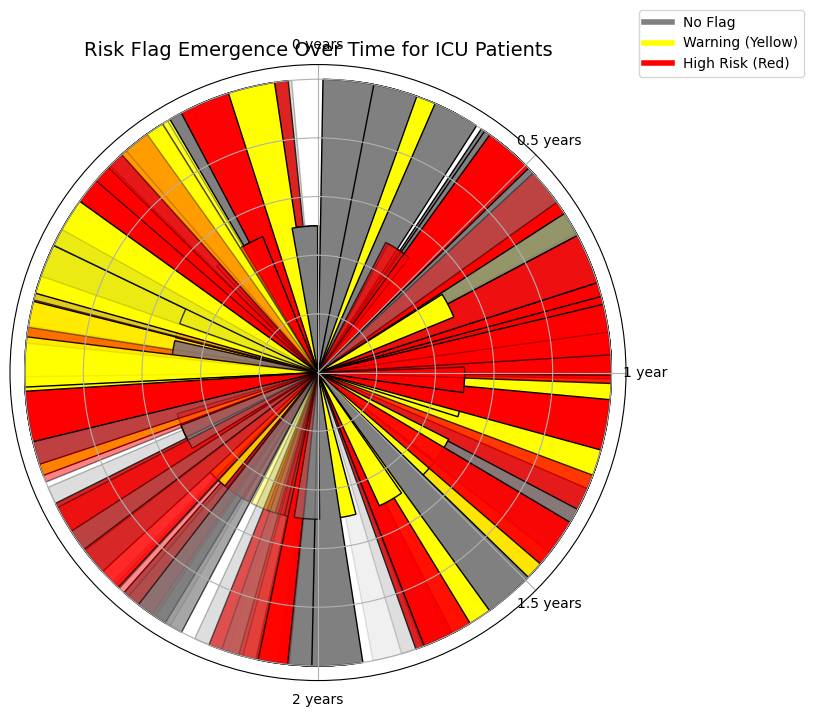

In [354]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
# 🔹 Define sample size
num_samples = 200

# 🔹 Generate Synthetic Data
np.random.seed(42)
time_before_event = np.random.uniform(0, 2, num_samples)  # New: Time from 0 to 2 years
q_values = np.random.rand(num_samples)  # Q-values between 0 and 1
attention_values = np.random.rand(num_samples)  # Attention values between 0 and 1
survival_status = np.random.choice([0, 1], num_samples, p=[0.3, 0.7])  # 70% Survivors
recommended_treatment = np.random.choice(["A", "B", "C", "D"], num_samples)  # Random treatments

# 🔹 Create DataFrame
df = pd.DataFrame({
    "time_before_event": time_before_event,
    "q_value": q_values,
    "attention_value": attention_values,
    "outcome": survival_status,
    "recommended_treatment": recommended_treatment
})




# 🔹 Load Your Data (Replace with actual paths)
# Q-values, actor predictions, attention values, patient status
# df = pd.read_csv("your_results.csv")  # Replace with actual file

# 🔹 Extract Relevant Data
time_years = df["time_before_event"]  # Time before ICU admission (negative values)
q_values = df["q_value"]  # Predicted Q-values
attention = df["attention_value"]  # Attention score for homelessness feature
survival_status = df["outcome"]  # 1 = Survivor, 0 = Non-Survivor
predicted_actions = df["recommended_treatment"]  # Suggested treatments

# 🔹 Normalize Q-values into flags (No-flag, Yellow, Red)
q_thresholds = [0.3, 0.6]  # Define risk thresholds (adjust as needed)
q_labels = np.digitize(q_values, bins=q_thresholds)
flag_colors = {0: "gray", 1: "yellow", 2: "red"}
# Convert time to angular coordinates
theta = np.radians((time_years / 2) * 360)  # Normalize to 0° to 360°

# 🔹 Set up Polar Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": "polar"})

# 🔹 Plot Bars for Each Time Bin
for i, (q, t, surv, att) in enumerate(zip(q_labels, theta, survival_status, attention)):
    color = flag_colors[q]
    bar_height = 1 if surv else 0.5  # Survivors taller than non-survivors
    alpha = att * 2  # Attention influences transparency
    alpha = np.clip(alpha, 0, 1)  # Ensure values stay between 0 and 1

    ax.bar(
        t, bar_height, width=np.radians(10), color=color, alpha=alpha, edgecolor="black"
    )

# 🔹 Add Labels and Legend
ax.set_theta_zero_location("N")  # Time = 0h at top
ax.set_theta_direction(-1)  # Clockwise
ax.set_xticks(np.radians(np.array([0, 0.5, 1, 1.5, 2]) * (180 / 2)))  # 0 to 2 years
ax.set_xticklabels(["0 years", "0.5 years", "1 year", "1.5 years", "2 years"])
ax.set_yticklabels([])  # Remove radial labels

# 🔹 Add Legends for Colors (Risk Flags)
legend_patches = [
    plt.Line2D([0], [0], color="gray", lw=4, label="No Flag"),
    plt.Line2D([0], [0], color="yellow", lw=4, label="Warning (Yellow)"),
    plt.Line2D([0], [0], color="red", lw=4, label="High Risk (Red)"),
]
ax.legend(handles=legend_patches, loc="upper right", bbox_to_anchor=(1.3, 1.1))

# 🔹 Show the Plot
plt.title("Risk Flag Emergence Over Time for ICU Patients", fontsize=14)
plt.show()


In [390]:
df.set_index("Step", inplace=True)

In [392]:
df.T

Step,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
Q-value,1.351238,4.832087,2.788544,1.736385,2.902338,0.695984,2.220219,3.131172,2.444489,2.008894,...,1.428918,1.016115,3.808991,1.932703,2.556377,2.461627,2.886395,4.327886,4.903697,2.037921
Reward,8.275189,7.645278,5.735290,9.560471,2.004745,1.092642,8.539620,4.391498,8.469689,8.930902,...,6.585405,7.661159,8.459214,6.136041,0.886047,4.876278,0.776493,4.075430,4.071065,0.660098
Uncertainty,0.348821,0.110998,0.808235,0.947688,0.072316,0.955115,0.522577,0.299566,0.076862,0.500624,...,0.822535,0.803959,0.552501,0.520170,0.142876,0.775346,0.271409,0.496695,0.284274,0.133828
Attention,0.629558,0.054332,0.748645,0.317587,0.000135,0.511129,0.046852,0.276170,0.706976,0.062690,...,0.298052,0.105365,0.781824,0.644149,0.048186,0.360050,0.956800,0.500401,0.432729,0.457700


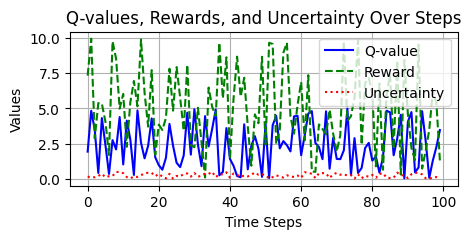

In [401]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 🔹 Generate sample data
num_steps = 100  # Number of steps (time series)
steps = np.arange(num_steps)  # X-axis: Steps
q_values = np.random.rand(num_steps) * 5  # Q-values
rewards = np.random.rand(num_steps) * 10  # Rewards
uncertainty = np.random.rand(num_steps) * 0.5  # Uncertainty

# 🔹 Create a DataFrame
df = pd.DataFrame({
    "Step": steps,
    "Q-value": q_values,
    "Reward": rewards,
    "Uncertainty": uncertainty
})

# 🔹 Plot each metric over time
plt.figure(figsize=(5, 2))
plt.plot(df["Step"], df["Q-value"], label="Q-value", color="blue", linestyle="-")
plt.plot(df["Step"], df["Reward"], label="Reward", color="green", linestyle="--")
plt.plot(df["Step"], df["Uncertainty"], label="Uncertainty", color="red", linestyle=":")

# 🔹 Labels and Formatting
plt.xlabel("Time Steps")
plt.ylabel("Values")
plt.title("Q-values, Rewards, and Uncertainty Over Steps")
plt.legend()
plt.grid(True)

# 🔹 Show plot
plt.show()


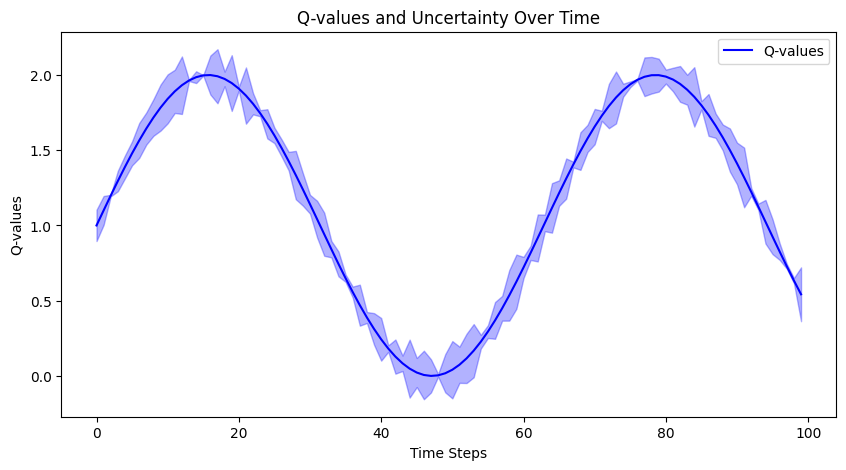

In [376]:
import matplotlib.pyplot as plt

# Simulated Data
time_steps = np.arange(100)
q_values = np.sin(time_steps / 10) + 1  # Simulated Q-values
uncertainty = np.random.rand(100) * 0.2  # Simulated uncertainty

# Plot
plt.figure(figsize=(10, 5))
plt.plot(time_steps, q_values, label="Q-values", color="blue")
plt.fill_between(time_steps, q_values - uncertainty, q_values + uncertainty, alpha=0.3, color="blue")

plt.xlabel("Time Steps")
plt.ylabel("Q-values")
plt.title("Q-values and Uncertainty Over Time")
plt.legend()
plt.show()


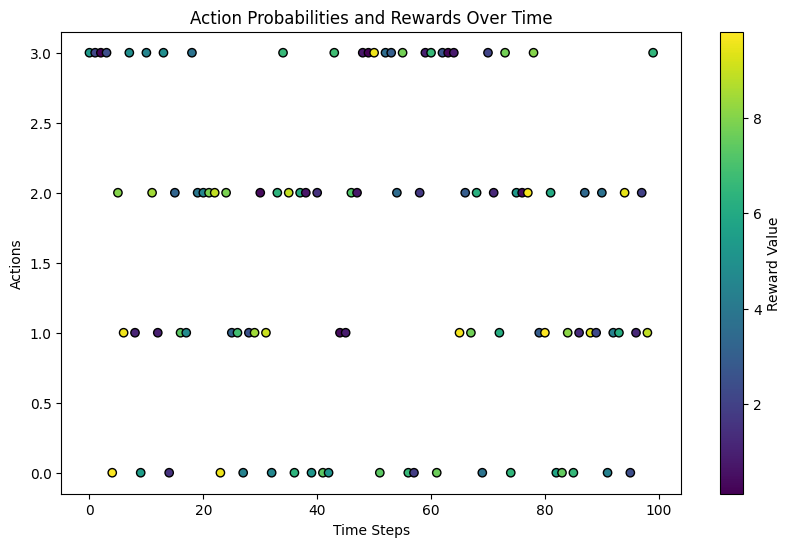

In [378]:
# Simulated Data
steps = np.arange(100)
actions = np.random.choice([0, 1, 2, 3], size=100)  # Actions (0-3)
rewards = np.random.rand(100) * 10  # Rewards

# Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(steps, actions, c=rewards, cmap="viridis", edgecolors="k")
plt.colorbar(label="Reward Value")
plt.xlabel("Time Steps")
plt.ylabel("Actions")
plt.title("Action Probabilities and Rewards Over Time")
plt.show()


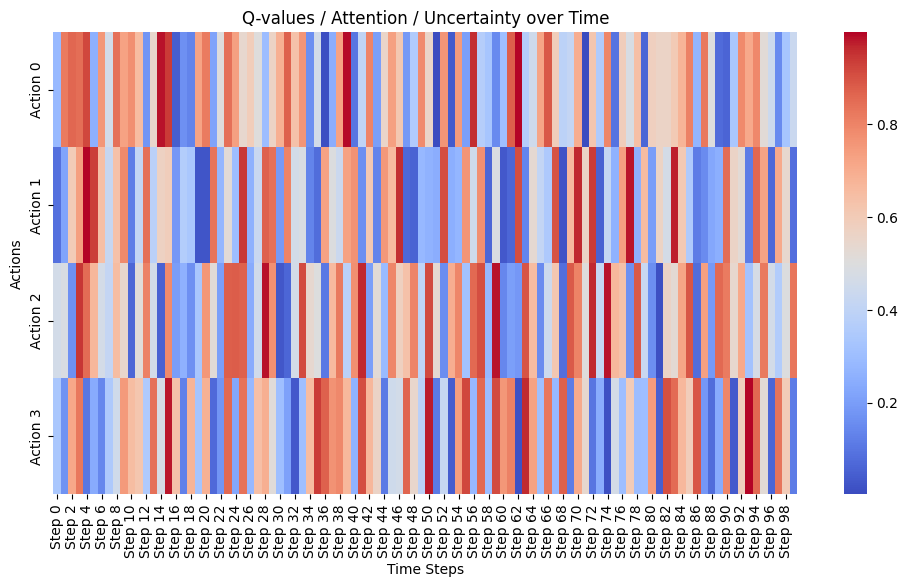

In [379]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Sample Data (Replace with real values)
steps = 100  # Number of steps
actions = 4  # Number of possible actions
data = np.random.rand(actions, steps)  # Simulated Q-values or attention scores

# Convert to DataFrame for Heatmap
df = pd.DataFrame(data, index=[f"Action {i}" for i in range(actions)], columns=[f"Step {i}" for i in range(steps)])

# Plot Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df, cmap="coolwarm", annot=False, cbar=True)
plt.xlabel("Time Steps")
plt.ylabel("Actions")
plt.title("Q-values / Attention / Uncertainty over Time")
plt.show()


In [6]:
import pickle
import pandas as pd

file_path = "results/rl_policies_autoencoder_train_cluster70_70_test_cluster_70_70_20250112-224409.pkl"

with open(file_path, "rb") as f:
    data = pickle.load(f)

print(data.keys())


dict_keys(['physician', 'optimal', 'greedy_physician'])


In [79]:
from itertools import product

# Define action columns
action_columns = ['Medication', 'Therapy', 'Counseling']

# Generate all possible one-hot combinations
one_hot_combinations = list(product([0, 1], repeat=len(action_columns)))

# Create mapping with meaningful labels
actions_dict = {}
for value in one_hot_combinations:
    active_treatments = [name for name, is_active in zip(action_columns, value) if is_active]
    
    if not active_treatments:
        label = "No Treatment"
    elif len(active_treatments) == 3:
        label = "All Treatments"
    else:
        label = " & ".join(active_treatments)

    actions_dict[label] = list(value)

# Ensure order of labels matches your policy's action indexing
labels_ordered = list(actions_dict.keys())


In [4]:
data.keys()

dict_keys(['physician', 'optimal', 'greedy_physician'])

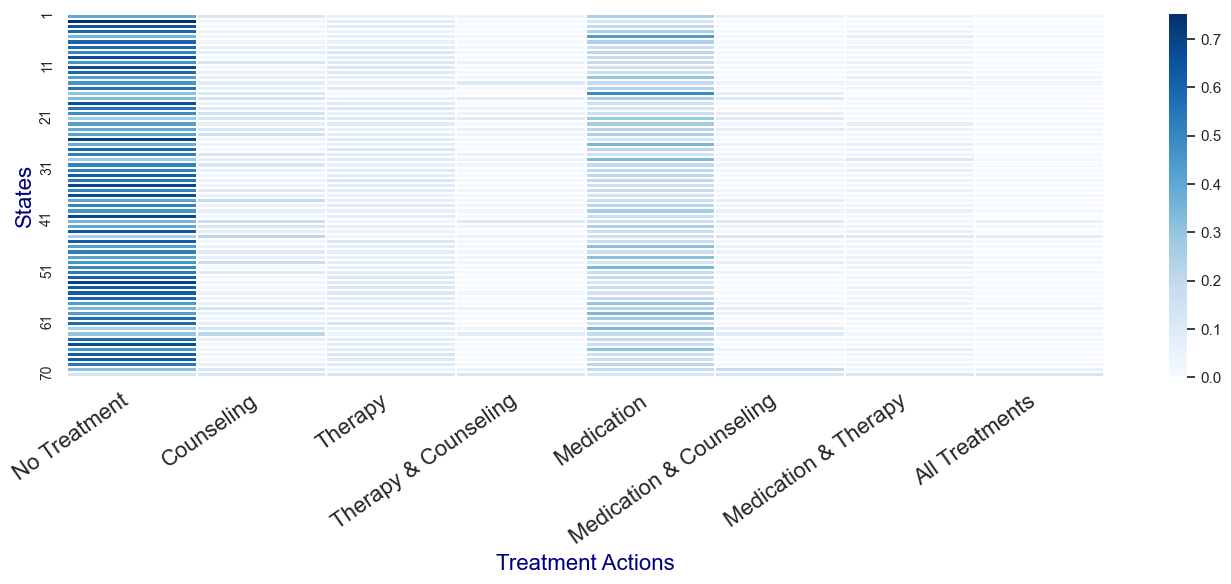

In [100]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
file_path = "results/rl_policies_autoencoder_train_cluster70_70_test_cluster_70_70_20250112-224409.pkl"
with open(file_path, "rb") as f:
    data = pickle.load(f)

# Replace 'physician_policy' with the actual key
physician_policy = data['physician']  

# Convert to numpy array if needed
policy_matrix = np.array(physician_policy)
num_states = policy_matrix.shape[0]  # should be 70 in your case
# Visualize policy
plt.figure(figsize=(14, 6))
sns.heatmap(policy_matrix, cmap="Blues", annot=False, linewidths=0.01, 
            xticklabels=labels_ordered)

# plt.title("Physician Policy Heatmap", fontsize=20)
plt.xlabel("Treatment Actions" , fontsize=16, color='navy')
# Set y-axis ticks from 1 to 70 with a step of 10

plt.ylabel("States", fontsize=16 , color='navy')
plt.xticks(rotation=35, ha='right', fontsize=16)
plt.yticks(
    np.arange(0, num_states, 10),      # tick positions: 0, 10, 20, ..., 60
    labels=[str(i+1) if i!=70 else i for i in np.arange(0, num_states, 10)],  # optional labels
    fontsize=10
)

plt.tight_layout()
plt.show()


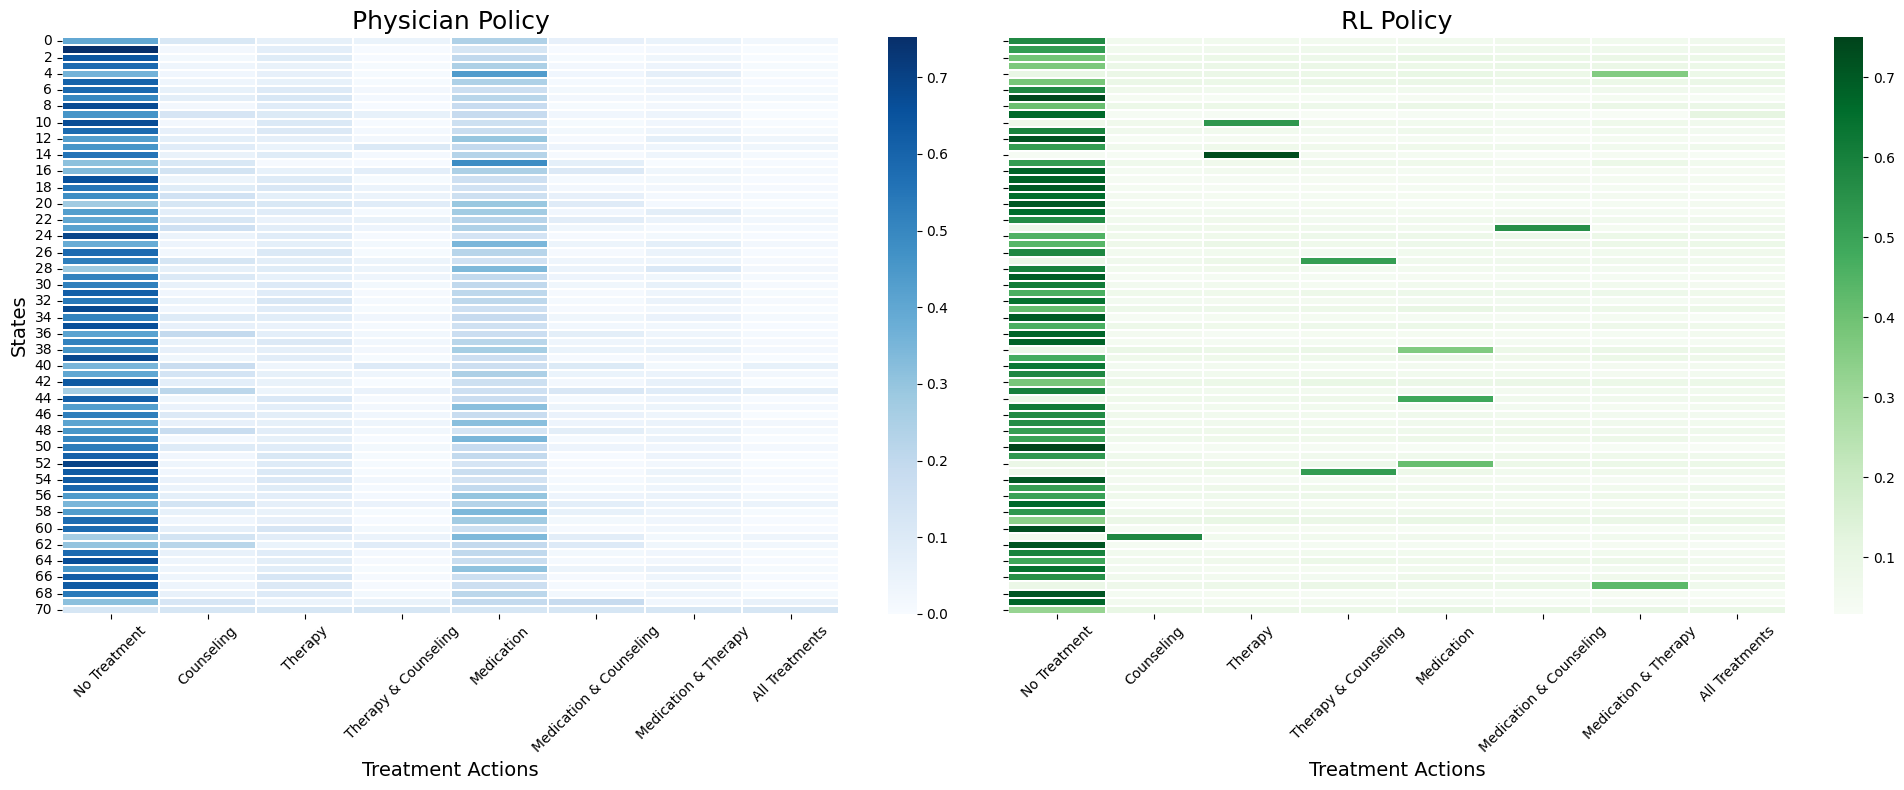

In [7]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
file_path = "results/rl_policies_autoencoder_train_cluster70_70_test_cluster_70_70_20250112-224409.pkl"
with open(file_path, "rb") as f:
    data = pickle.load(f)

# Extract policies
physician_policy = np.array(data['physician'])
rl_policy = np.array(data['optimal'])  # Assuming 'rl' key exists for RL policy

# Define action labels
from itertools import product
action_columns = ['Medication', 'Therapy', 'Counseling']
one_hot_combinations = list(product([0, 1], repeat=len(action_columns)))

actions_dict = {}
for value in one_hot_combinations:
    active_treatments = [name for name, is_active in zip(action_columns, value) if is_active]
    if not active_treatments:
        label = "No Treatment"
    elif len(active_treatments) == 3:
        label = "All Treatments"
    else:
        label = " & ".join(active_treatments)
    actions_dict[label] = list(value)
labels_ordered = list(actions_dict.keys())

# Plot side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

sns.heatmap(physician_policy, cmap="Blues", ax=axes[0], xticklabels=labels_ordered,
            annot=False, linewidths=0.01)
axes[0].set_title("Physician Policy", fontsize=18)
axes[0].set_xlabel("Treatment Actions", fontsize=14)
axes[0].set_ylabel("States", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(rl_policy, cmap="Greens", ax=axes[1], xticklabels=labels_ordered,
            annot=False, linewidths=0.01)
axes[1].set_title("RL Policy", fontsize=18)
axes[1].set_xlabel("Treatment Actions", fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_2749/3865370652.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(df["Label"], rotation=45, ha='right')
/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_2749/3865370652.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(df["Label"], rotation=45, ha='right')
/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_2749/3865370652.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(df["Label"], rotation=45, ha='right')


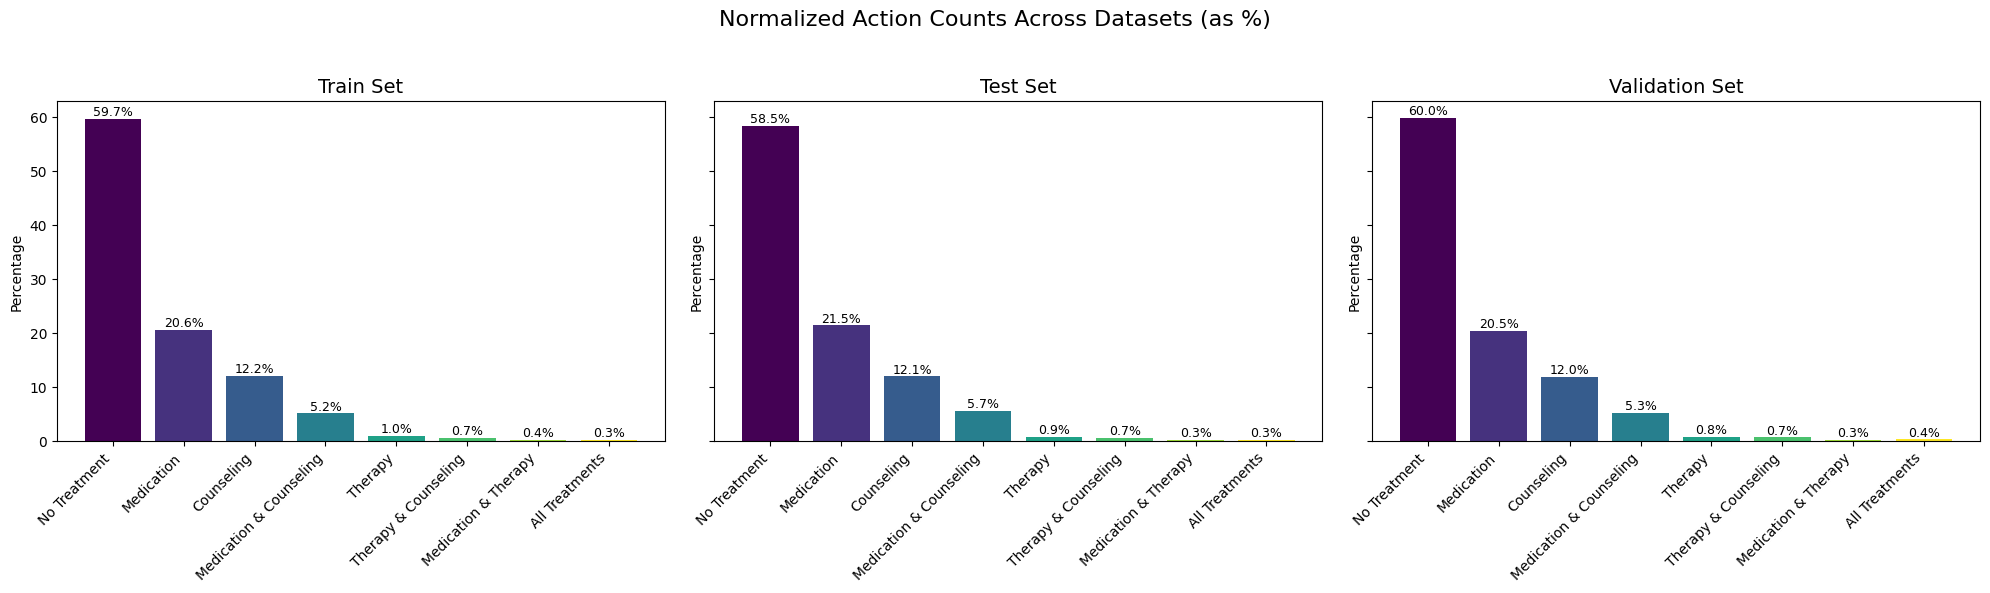

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from itertools import product

# Define action columns and generate labels
action_columns = ['Medication', 'Therapy', 'Counseling']
one_hot_combinations = list(product([0, 1], repeat=len(action_columns)))

actions_dict = {}
for value in one_hot_combinations:
    active_treatments = [name for name, is_active in zip(action_columns, value) if is_active]
    if not active_treatments:
        label = "No Treatment"
    elif len(active_treatments) == 3:
        label = "All Treatments"
    else:
        label = " & ".join(active_treatments)
    actions_dict[label] = list(value)

labels_ordered = list(actions_dict.keys())

# Action counts from datasets
train_counts = {0: 2419832, 1: 493316, 4: 835761, 3: 26611, 2: 40340, 5: 212036, 6: 14411, 7: 11172}
test_counts = {4: 108986, 5: 28839, 0: 296577, 1: 61171, 3: 3462, 2: 4609, 7: 1766, 6: 1602}
val_counts = {5: 23820, 4: 92851, 0: 271575, 2: 3740, 1: 54174, 3: 3395, 7: 1766, 6: 1486}

# Create DataFrame
df = pd.DataFrame({
    "Action": list(range(8)),
    "Label": labels_ordered,
    "Train": [train_counts.get(i, 0) for i in range(8)],
    "Test": [test_counts.get(i, 0) for i in range(8)],
    "Validation": [val_counts.get(i, 0) for i in range(8)]
})

# Normalize to percentages
df["Train"] = df["Train"] / df["Train"].sum() * 100
df["Test"] = df["Test"] / df["Test"].sum() * 100
df["Validation"] = df["Validation"] / df["Validation"].sum() * 100

# Sort by Train frequency
df.sort_values("Train", ascending=False, inplace=True)
x = np.arange(len(df))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
datasets = ["Train", "Test", "Validation"]
colors = plt.cm.viridis(np.linspace(0, 1, len(df)))

for i, dataset in enumerate(datasets):
    axes[i].bar(df["Label"], df[dataset], color=colors)
    axes[i].set_title(f"{dataset} Set", fontsize=14)
    axes[i].set_xticklabels(df["Label"], rotation=45, ha='right')
    axes[i].set_ylabel("Percentage")
    for idx, val in enumerate(df[dataset]):
        axes[i].text(idx, val + 0.5, f"{val:.1f}%", ha='center', fontsize=9)

fig.suptitle("Normalized Action Counts Across Datasets (as %)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# No treatment 59.7%, medication 20.6%, counseling 12.2%, medicatoin and counseling 5.2%, therapy 1%, 
# therapy and counseling 0.7%, therapy and medication 0.4%, all treatments 0.3% 

In [ ]:
from d3rlCQL import DiscreteCQLConfig_H
import d3rlpy
from d3rlpy import algos
from RLModels_2layer import *
import torch
import torch.nn as nn
from d3rlpy import load_learnable

In [ ]:
/Users/fuzzysha/Desktop/PHD_plan/Codes/paper_codes/RL/results/DQ_resutls/resultsUHA-CQL/e_1test_rlUHA-CQL_cl70_ec70_ld64_ly2_hn64_afrelu_lrA1e-05_lrC0.0001_st1000000_uA(False-0.0|False-0.0)_uC(True-0.01|False-0.0)_att1(True-h1)_att2(False-h1)_250401-1847.xlsx

In [7]:
pwd

'/Users/fuzzysha/Desktop/PHD_plan/Codes/paper_codes/RL/src/Qlearning'

In [13]:
# model = "./././results/DQ_resutls/resultsUHA-CQL/-CQL_cl70_ec70_ld64_ly2_hn64_afrelu_lrA1e-05_lrC0.0001_st1000000_uA(False-0.0|False-0.0)_uC(True-0.01|False-0.0)_att1(True-h1)_att2(False-h1)_250401-1847.d3"
model ="/Users/fuzzysha/Desktop/PHD_plan/Codes/paper_codes/RL/results/resultsUHA-CQL/UHA-CQL_cl70_ec70_ld64_ly2_hn64_afrelu_lrA1e-05_lrC0.0001_st1000_uA(False-1.0|False-1.0)_uC(False-1.0|False-1.0)_att1(False-h4)_att2(False-h4)_250401-1411.d3"
rl_model = load_learnable(model)

/opt/anaconda3/envs/project/lib/python3.11/site-packages/d3rlpy/torch_utility.py:431: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chkpt = torch.load(f, map_location=map_lo

In [14]:
rl_policy = PolicyResolver(rl_model, list(action_dict_level_2.keys()))
rl_greedy_policy = PolicyResolver(rl_model, list(action_dict_level_2.keys()), greedy=True)
physician_policy = PolicyResolver('best_physician_policy', list(action_dict_level_2.keys()))
physician_policy_greedy = PolicyResolver('best_physician_policy', list(action_dict_level_2.keys()), greedy=True)

        

NameError: name 'PolicyResolver' is not defined

In [ ]:
model_params = {

        'num_layers': 2,
        'num_hidden_neurons': 64,
        'activation_func': 'relu',
        'actor_learning_rate': 0.0001,
        'critic_learning_rate': 0.0001,
        'learning_rate': 0.0001,
        'n_steps': 1000,
        'conservative_alpha' : 1,
        'batch_size': 64,
        'gamma': 0.99,  
        'n_epochs':1,
        'n_steps_per_epoch': 1000,
        'n_updates_per_epoch': 1000,
        'target_update_interval': 1000,
        'eval_interval': 1000,
        'log_interval': 1000,

        # Actor parameters for the encoder factory
        'num_actor_layers': 2,
        'num_actor_hidden_neurons': 64,
        'actor_activation_func': 'relu',

        # UHA_SAC leavel 1 parameters
        "use_uncertainty_actor_loss_1": False,
        "use_uncertainty_critic_loss_1": False,
        "uncertainty_critic_weight_1": 0.00001,
        "uncertainty_actor_weight_1": 0.00001,
        "use_attention_1": False,
        "num_attention_heads_1": 1,

        # UHA_SAC leavel 2 parameters
        "use_uncertainty_actor_loss_2": False,
        "use_uncertainty_critic_loss_2": False,
        "uncertainty_critic_weight_2": 0.0001,
        "uncertainty_actor_weight_2":  0.001,
        "use_attention_2": False,
        "num_attention_heads_2": 1,

    }



 
# # for CQL
# if conservative_alpha is not None:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
algo = "UHA-CQL"
DQmodel = DQNModel(algo, model_params, str(device))

# fit the model
# rl_model = DQmodel.fit_model(train_d3r_dataset, experiment_name)

rl_algo = DQmodel._get_model(algo=algo)

In [ ]:
from utils import PolicyResolver, WeightedImportanceSampling, Encoder, DatasetFromEpisodes, LoadEpisodes
from  config.config_param import config_param
dsEpisodes = DatasetFromEpisodes()
config_params = config_param()
# read the data from config
param_dic = config_params.get_params_updated()
le = LoadEpisodes(param_dic)
train_data_encObs = pd.concat([train_data, load_encoder.return_encod_obs(train_path, latent_dim, ob_prefix, param_dic['models_path'])], axis=1)
test_data_encObs = pd.concat([test_data, load_encoder.return_encod_obs(test_path, latent_dim, ob_prefix, param_dic['models_path'])], axis=1)
val_data_encObs = pd.concat([val_data, load_encoder.return_encod_obs(val_path, latent_dim, ob_prefix, param_dic['models_path'])], axis=1)

train_episodes_encObs , train_episodes_cluster , train_episodes_encoder_cluster = le.load_episodes(train_data_encObs, cluster_col_train, cluster_encoder_col_train)
test_episodes_encObs, test_episodes_cluster, test_episodes_encoder_cluster = le.load_episodes(test_data_encObs, cluster_col_test, cluster_encoder_col_test) #train_episodes_raw , train_episodes_cluster , train_episodes_encoder_cluster#le.load_episodes('test')
val_episodes_encObs, val_episodes_cluster, val_episodes_encoder_cluster = le.load_episodes(val_data_encObs, cluster_col_val, cluster_encoder_col_val)#train_episodes_raw , train_episodes_cluster , train_episodes_encoder_cluster#le.load_episodes('val')


train_d3r_dataset = dsEpisodes.get_d3rlpy_dataset_fixed(train_episodes_encObs, action_dict_level_2)

In [ ]:
rl_algo.build_with_dataset(train_d3r_dataset)

AttributeError: 'DiscreteCQL' object has no attribute 'build'

AssertionError: The neural network parameters are not initialized. Pleaes call build_with_dataset, build_with_env, or directly call fit or fit_online method.

In [ ]:
# Set the root directory
import os
import glob


/Users/fuzzysha/Desktop/PHD_plan/Codes/paper_codes/RL/DQ_resutls/


In [51]:
d3_files

['/Users/fuzzysha/Desktop/PHD_plan/Codes/paper_codes/RL/DQ_resutls/resultsUHA-SAC/UHA-SAC_cl70_ec70_ld64_ly2_hn64_afrelu_lrA1e-05_lrC0.0001_st1000000_uA(False-0.0|False-0.0)_uC(True-0.01|True-0.0001)_att1(True-h1)_att2(True-h1)_250402-0900.d3',
 '/Users/fuzzysha/Desktop/PHD_plan/Codes/paper_codes/RL/DQ_resutls/resultsUHA-SAC/UHA-SAC_cl70_ec70_ld64_ly2_hn64_afrelu_lrA1e-05_lrC0.0001_st1000000_uA(False-0.0|False-0.0)_uC(True-0.01|True-0.01)_att1(True-h2)_att2(True-h1)_250401-2047.d3',
 '/Users/fuzzysha/Desktop/PHD_plan/Codes/paper_codes/RL/DQ_resutls/resultsUHA-SAC/UHA-SAC_cl70_ec70_ld64_ly2_hn64_afrelu_lrA1e-05_lrC0.0001_st1000000_uA(False-0.0|False-0.0)_uC(True-0.0001|True-0.0001)_att1(True-h1)_att2(True-h2)_250401-2043.d3',
 '/Users/fuzzysha/Desktop/PHD_plan/Codes/paper_codes/RL/DQ_resutls/resultsUHA-SAC/UHA-SAC_cl70_ec70_ld64_ly2_hn64_afrelu_lrA1e-05_lrC0.0001_st1000000_uA(False-0.0|False-0.0)_uC(True-0.01|True-0.01)_att1(True-h2)_att2(True-h1)_250402-0900.d3',
 '/Users/fuzzysha/Desk

/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_87503/3665374407.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='policy', y='WIS', data=df, palette='Set1', ax=axes[0, 0])
/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_87503/3665374407.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='policy', y='reward', data=df, palette='Set2', ax=axes[0, 1])
/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_87503/3665374407.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='selected_action', y='WIS', da

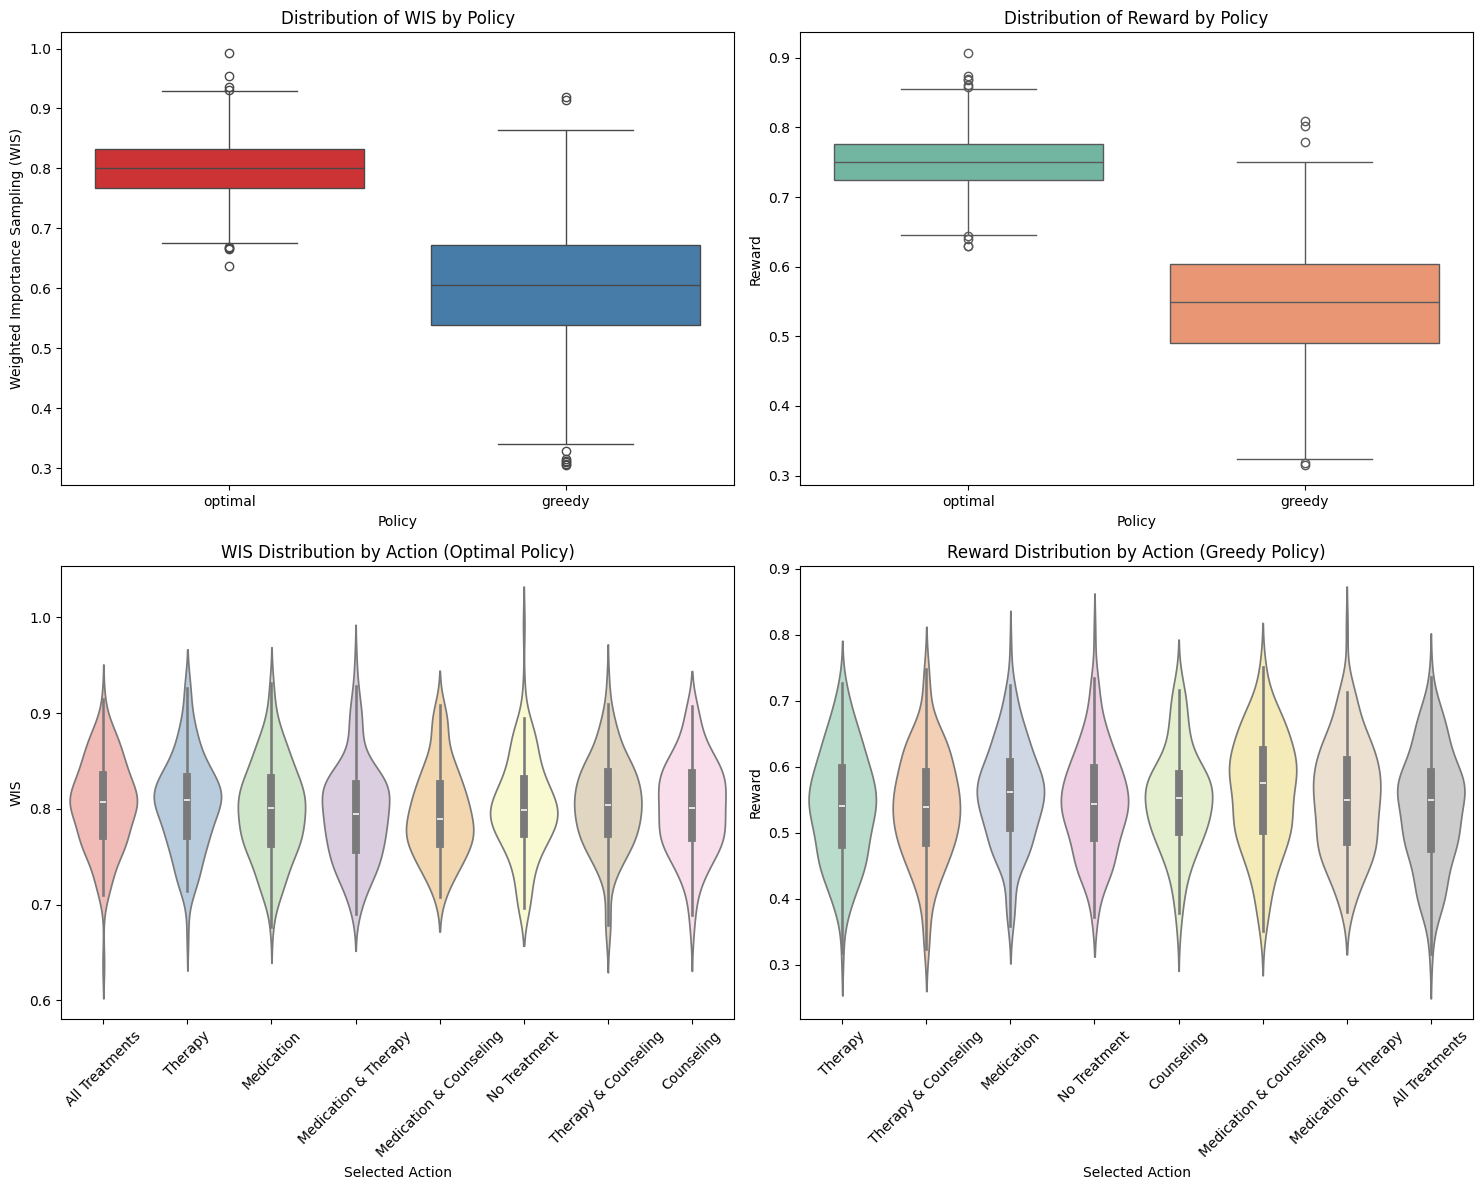

In [3]:
import pandas as pd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create sample data
np.random.seed(42)  # for reproducible results
n_bootstrap = 1000

policies = ['optimal', 'greedy']
actions = ['No Treatment', 'Medication', 'Therapy', 'Counseling', 'Medication & Therapy', 
           'Medication & Counseling', 'Therapy & Counseling', 'All Treatments']

# Generate random bootstrap results
data = {
    'bootstrap_iteration': np.tile(np.arange(1, n_bootstrap + 1), len(policies)),
    'policy': np.repeat(policies, n_bootstrap),
    'WIS': np.concatenate([np.random.normal(loc=0.8, scale=0.05, size=n_bootstrap),
                           np.random.normal(loc=0.6, scale=0.1, size=n_bootstrap)]),
    'reward': np.concatenate([np.random.normal(loc=0.75, scale=0.04, size=n_bootstrap),
                              np.random.normal(loc=0.55, scale=0.08, size=n_bootstrap)]),
    'selected_action': np.random.choice(actions, size=n_bootstrap * len(policies))
}

df = pd.DataFrame(data)


# Set figure
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Boxplot: WIS by Policy (optimal vs greedy)
sns.boxplot(x='policy', y='WIS', data=df, palette='Set1', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of WIS by Policy')
axes[0, 0].set_xlabel('Policy')
axes[0, 0].set_ylabel('Weighted Importance Sampling (WIS)')

# Boxplot: Reward by Policy
sns.boxplot(x='policy', y='reward', data=df, palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Reward by Policy')
axes[0, 1].set_xlabel('Policy')
axes[0, 1].set_ylabel('Reward')

# Violin plot: WIS vs Selected Action (Optimal policy)
sns.violinplot(x='selected_action', y='WIS', data=df[df['policy'] == 'optimal'],
               palette='Pastel1', ax=axes[1, 0])
axes[1, 0].set_title('WIS Distribution by Action (Optimal Policy)')
axes[1, 0].set_xlabel('Selected Action')
axes[1, 0].set_ylabel('WIS')
axes[1, 0].tick_params(axis='x', rotation=45)

# Violin plot: Reward vs Selected Action (Greedy policy)
sns.violinplot(x='selected_action', y='reward', data=df[df['policy'] == 'greedy'],
               palette='Pastel2', ax=axes[1, 1])
axes[1, 1].set_title('Reward Distribution by Action (Greedy Policy)')
axes[1, 1].set_xlabel('Selected Action')
axes[1, 1].set_ylabel('Reward')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
df = pd.read_csv("offline_rl_results.csv")

In [ ]:
sns.scatterplot(
    data=subset,
    x='behavior_probs',
    y='rl_prob',
    hue='agreement',  # True/False for agreement
    palette={True: 'green', False: 'red'},
    alpha=0.6
)

Index(['subject_id', 'actions', 'behavior_probs', 'rewards', 'w_i',
       'total_reward', 'gamma', 'best_action', 'true_action', 'rl_prob'],
      dtype='object')

In [76]:
df['rl_prob'].value_counts()

rl_prob
1.000000    342378
0.000001    139417
Name: count, dtype: int64

/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_58036/1991764349.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['agreement'] = subset['behavior_probs'] == subset['rl_prob']


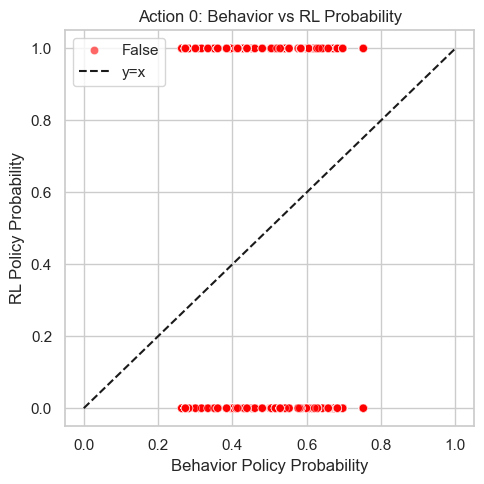

/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_58036/1991764349.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['agreement'] = subset['behavior_probs'] == subset['rl_prob']


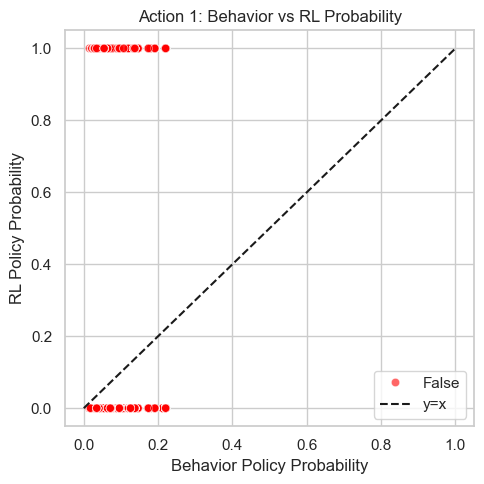

/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_58036/1991764349.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['agreement'] = subset['behavior_probs'] == subset['rl_prob']


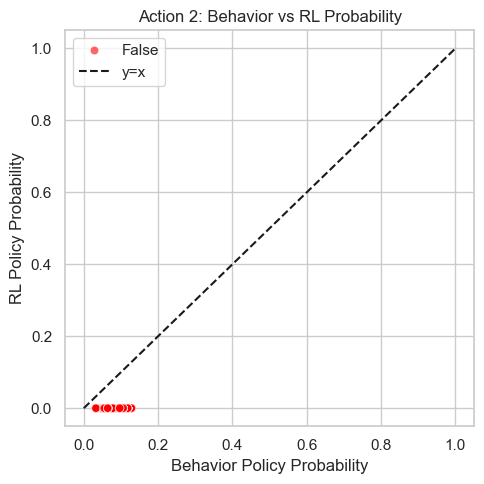

/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_58036/1991764349.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['agreement'] = subset['behavior_probs'] == subset['rl_prob']


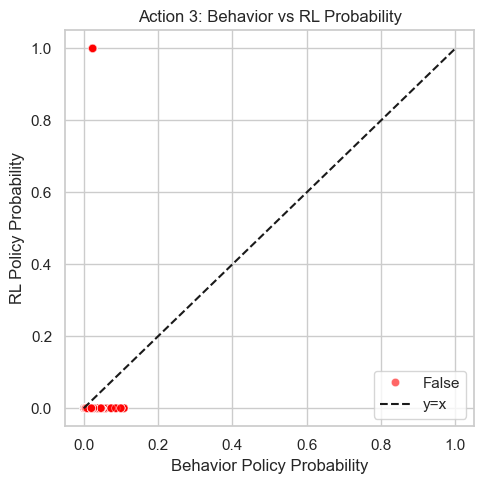

/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_58036/1991764349.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['agreement'] = subset['behavior_probs'] == subset['rl_prob']


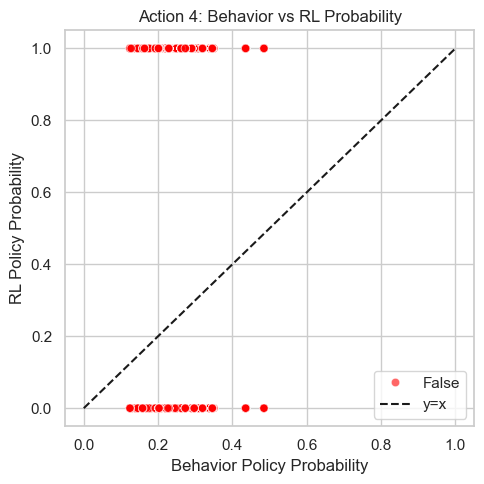

/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_58036/1991764349.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['agreement'] = subset['behavior_probs'] == subset['rl_prob']


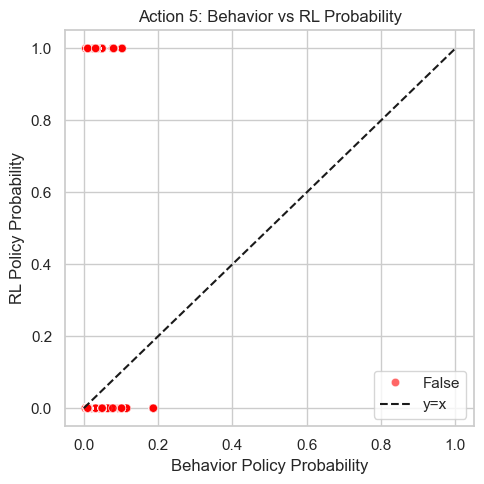

/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_58036/1991764349.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['agreement'] = subset['behavior_probs'] == subset['rl_prob']


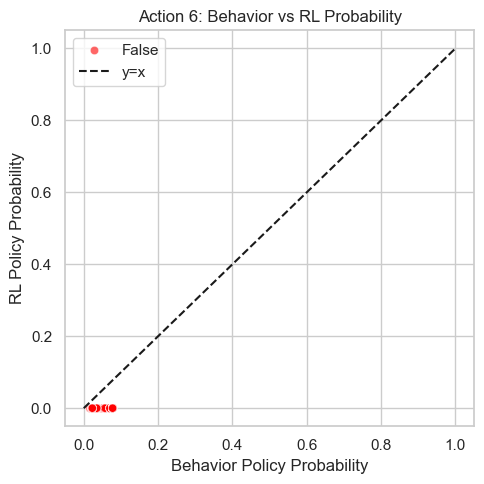

/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_58036/1991764349.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['agreement'] = subset['behavior_probs'] == subset['rl_prob']


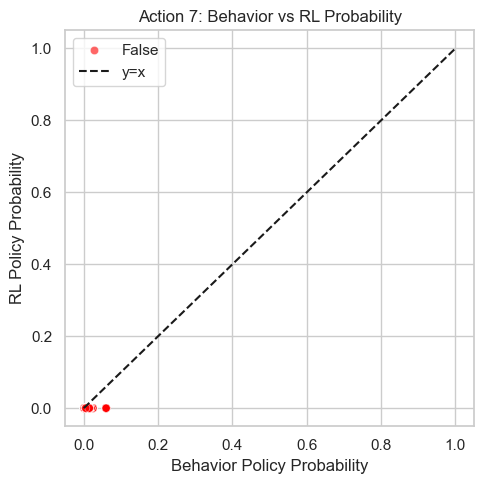

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

# loop through each unique action
for action_id in sorted(df['actions'].unique()):
    subset = df[df['actions'] == action_id]
    subset['agreement'] = subset['behavior_probs'] == subset['rl_prob']

    plt.figure(figsize=(5, 5))
    sns.scatterplot(data=subset, 
                    x='behavior_probs', 
                    y='rl_prob', 
                    hue='agreement',  # True/False for agreement
                    palette={True: 'green', False: 'red'},
                    alpha=0.6)
    plt.title(f"Action {action_id}: Behavior vs RL Probability")
    plt.plot([0, 1], [0, 1], 'k--', label='y=x')  # Diagonal line for reference
    
    plt.xlabel("Behavior Policy Probability")
    plt.ylabel("RL Policy Probability")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


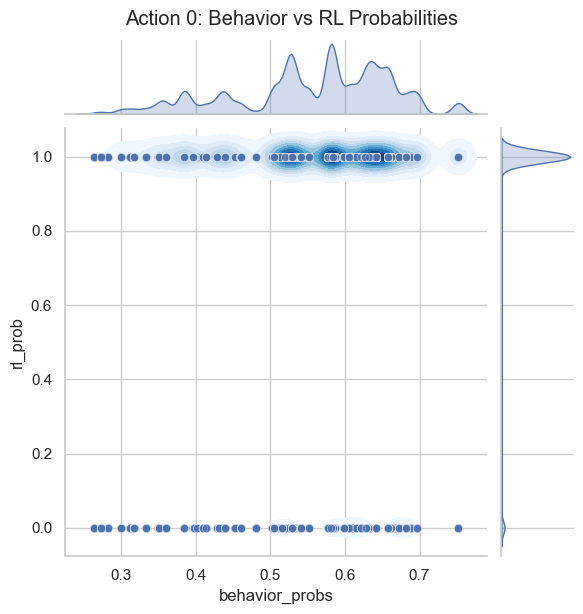

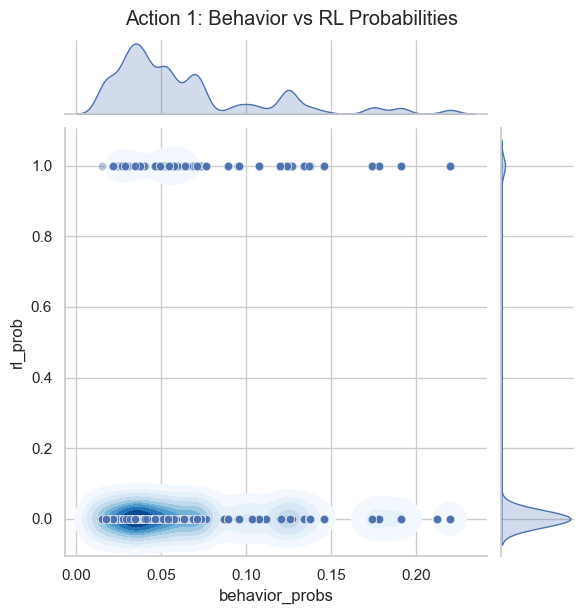

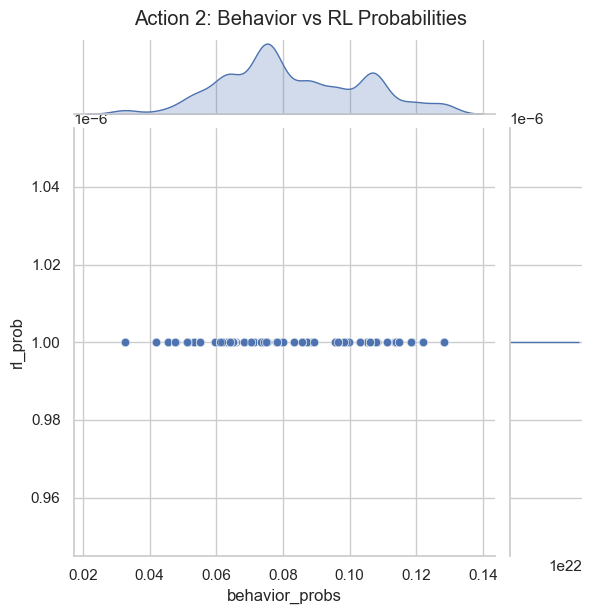

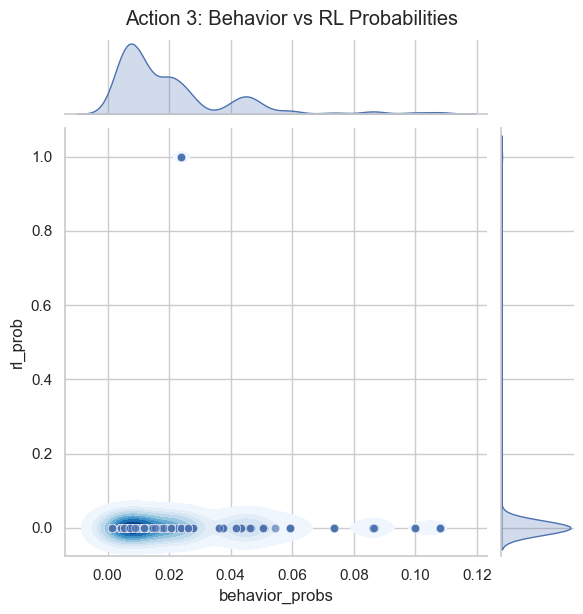

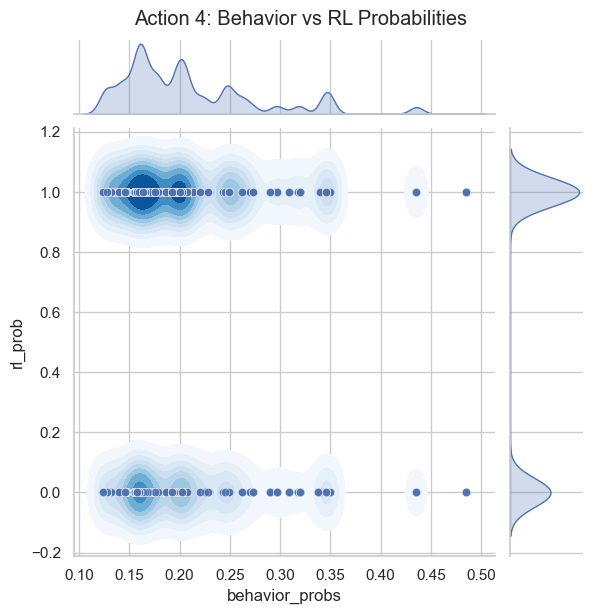

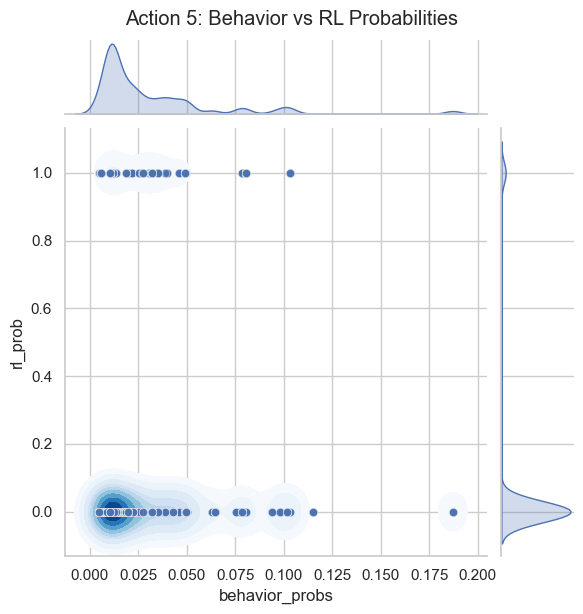

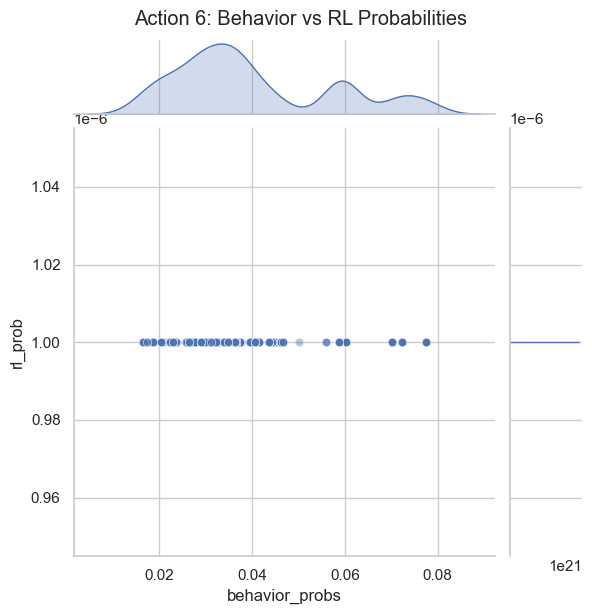

/opt/anaconda3/envs/project/lib/python3.11/site-packages/seaborn/axisgrid.py:1889: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(y=self.y, ax=self.ax_marg_y, **kwargs)


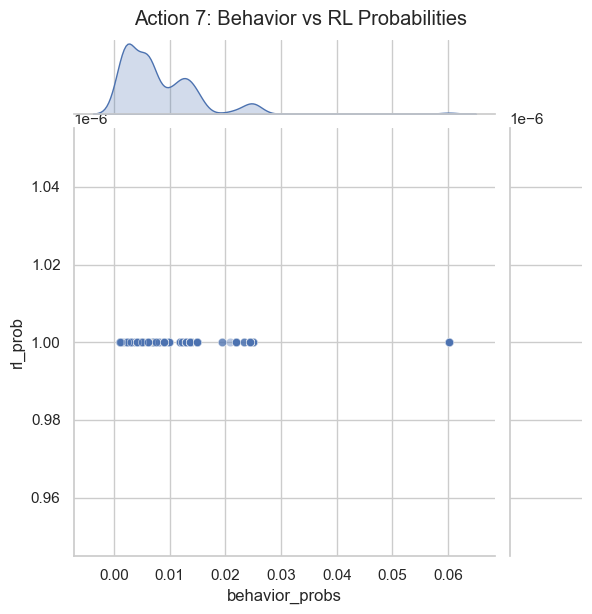

In [70]:
for action_id in sorted(df['actions'].unique()):
    subset = df[df['actions'] == action_id]
    
    sns.jointplot(
        data=subset,
        x='behavior_probs',
        y='rl_prob',
        kind='kde',
        fill=True,
        cmap="Blues"
    ).plot_joint(sns.scatterplot, alpha=0.4)
    plt.suptitle(f"Action {action_id}: Behavior vs RL Probabilities", y=1.02)
    plt.show()


In [62]:
grouped =df.groupby(['best_action', 'true_action'])
for action, group in grouped:
    print(f"Action: {action}")
    agreement_rate = (group['best_action'] == group['true_action']).mean()
    print(f"Agreement Rate: {agreement_rate:.2f}")



Action: (0, '0')
Agreement Rate: 0.00
Action: (0, '1')
Agreement Rate: 0.00
Action: (0, '2')
Agreement Rate: 0.00
Action: (0, '3')
Agreement Rate: 0.00
Action: (0, '4')
Agreement Rate: 0.00
Action: (0, '5')
Agreement Rate: 0.00
Action: (0, '6')
Agreement Rate: 0.00
Action: (0, '7')
Agreement Rate: 0.00
Action: (1, '0')
Agreement Rate: 0.00
Action: (1, '1')
Agreement Rate: 0.00
Action: (1, '2')
Agreement Rate: 0.00
Action: (1, '3')
Agreement Rate: 0.00
Action: (1, '4')
Agreement Rate: 0.00
Action: (1, '5')
Agreement Rate: 0.00
Action: (1, '6')
Agreement Rate: 0.00
Action: (1, '7')
Agreement Rate: 0.00
Action: (3, '0')
Agreement Rate: 0.00
Action: (3, '1')
Agreement Rate: 0.00
Action: (3, '3')
Agreement Rate: 0.00
Action: (4, '0')
Agreement Rate: 0.00
Action: (4, '1')
Agreement Rate: 0.00
Action: (4, '2')
Agreement Rate: 0.00
Action: (4, '3')
Agreement Rate: 0.00
Action: (4, '4')
Agreement Rate: 0.00
Action: (4, '5')
Agreement Rate: 0.00
Action: (4, '6')
Agreement Rate: 0.00
Action: (4, 

/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_58036/715336120.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agreement_by_subject = df.groupby('best_action').apply(lambda x: (x['best_action'] == x['true_action']).mean())


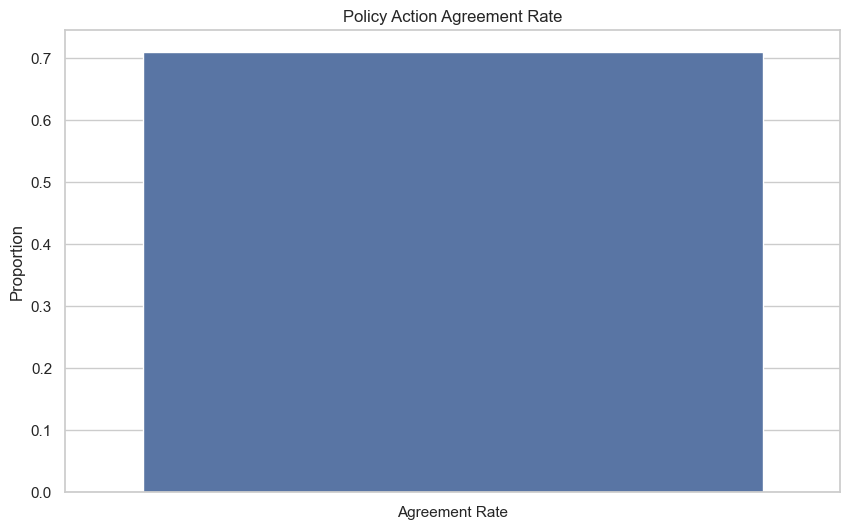

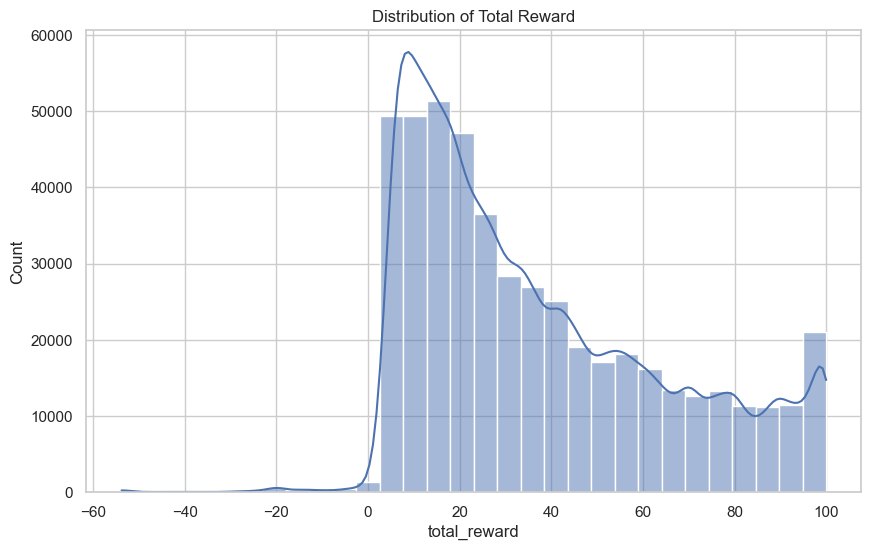

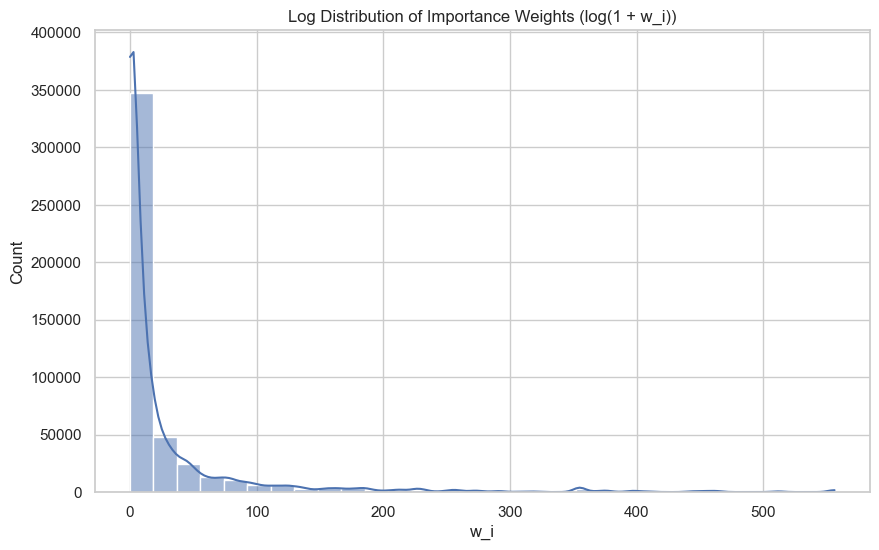

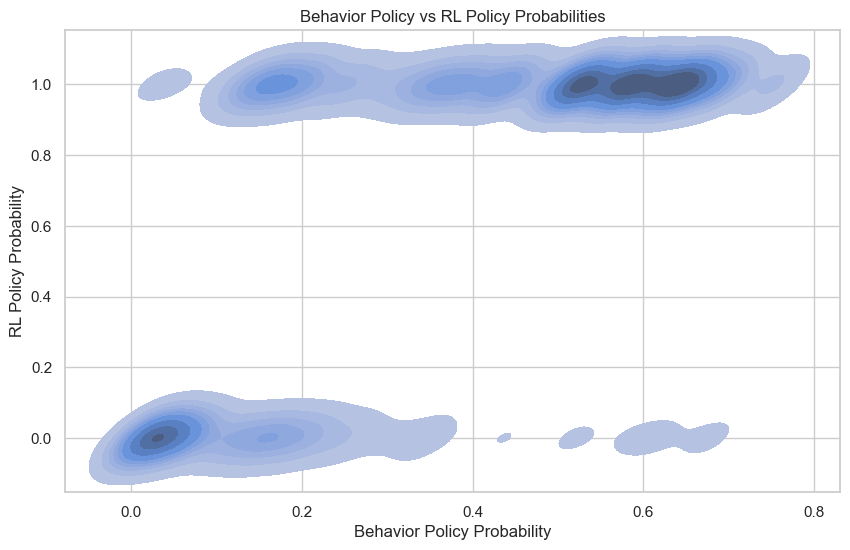

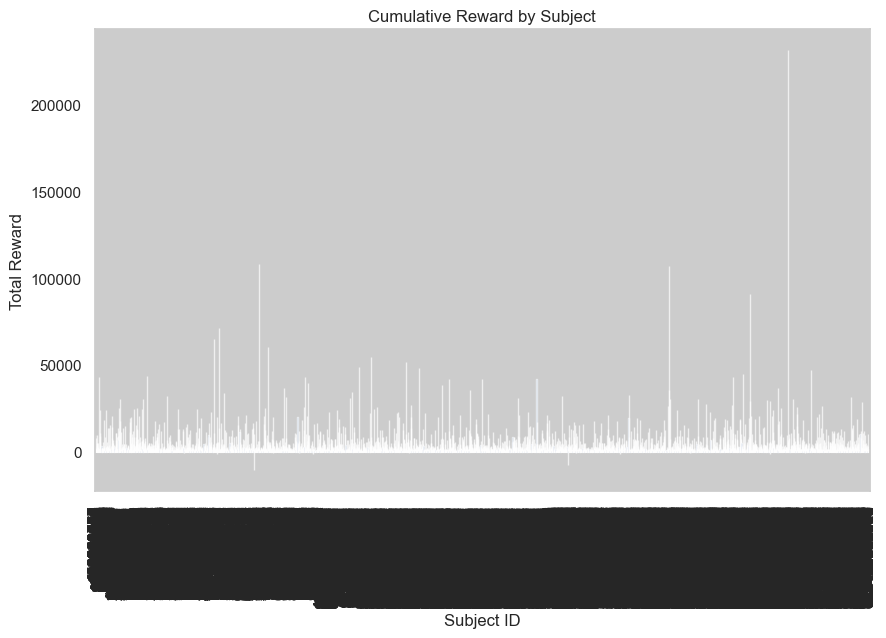

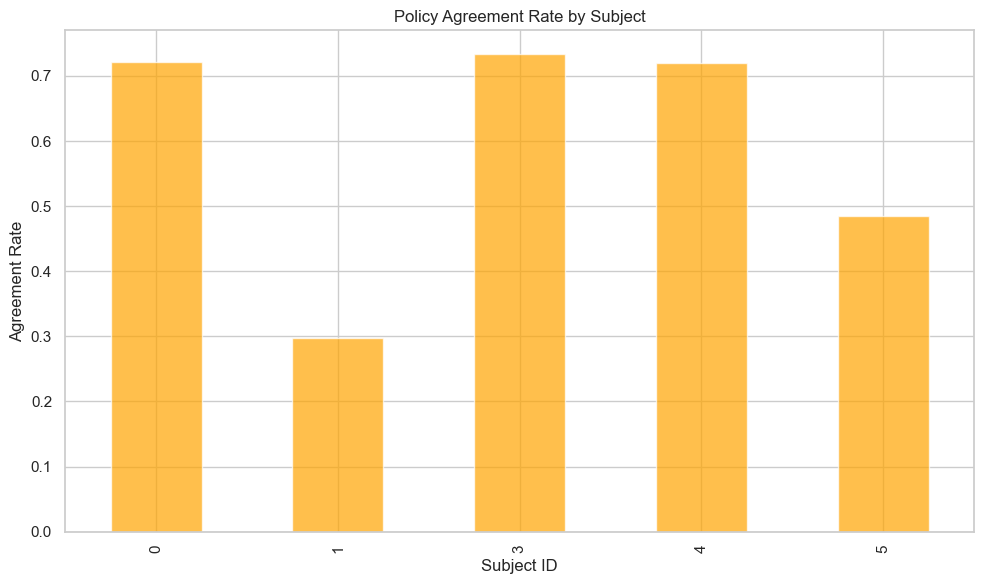

In [ ]:


# Set up the plotting environment
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. Policy Action Agreement
agreement_rate = (df['best_action'] == df['true_action']).mean()

# 2. Reward Distribution
reward_distribution = df['total_reward']

# 3. Importance Weights (log distribution)
log_importance_weights = np.log1p(df['w_i'])

# 4. RL vs Behavior Policy
behavior_probs = df['behavior_probs']
rl_probs = df['rl_prob']

# 5. Per-Subject Cumulative Reward & Agreement
reward_by_subject = df.groupby('subject_id')['total_reward'].sum()
agreement_by_subject = df.groupby('best_action').apply(lambda x: (x['best_action'] == x['true_action']).mean())

# Plotting all in separate figures
# 1. Policy Action Agreement
plt.figure()
sns.barplot(x=['Agreement Rate'], y=[agreement_rate])
plt.title("Policy Action Agreement Rate")
plt.ylabel("Proportion")

# 2. Reward Distribution
plt.figure()
sns.histplot(reward_distribution, bins=30, kde=True)
plt.title("Distribution of Total Reward")

# 3. Log Distribution of Importance Weights
plt.figure()
sns.histplot(log_importance_weights, bins=30, kde=True)
plt.title("Log Distribution of Importance Weights (log(1 + w_i))")

# 4. Behavior vs RL Probabilities
plt.figure()
sns.kdeplot(x=behavior_probs, y=rl_probs, fill=True)
plt.title("Behavior Policy vs RL Policy Probabilities")
plt.xlabel("Behavior Policy Probability")
plt.ylabel("RL Policy Probability")

# 5. Per-Subject Cumulative Reward & Agreement
plt.figure()
reward_by_subject.plot(kind='bar', alpha=0.7, label='Total Reward')
plt.title("Cumulative Reward by Subject")
plt.xlabel("Subject ID")
plt.ylabel("Total Reward")

plt.figure()
agreement_by_subject.plot(kind='bar', color='orange', alpha=0.7, label='Agreement Rate')
plt.title("Policy Agreement Rate by Subject")
plt.xlabel("Subject ID")
plt.ylabel("Agreement Rate")

plt.tight_layout()
plt.show()


/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_58036/1861252526.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Policy")


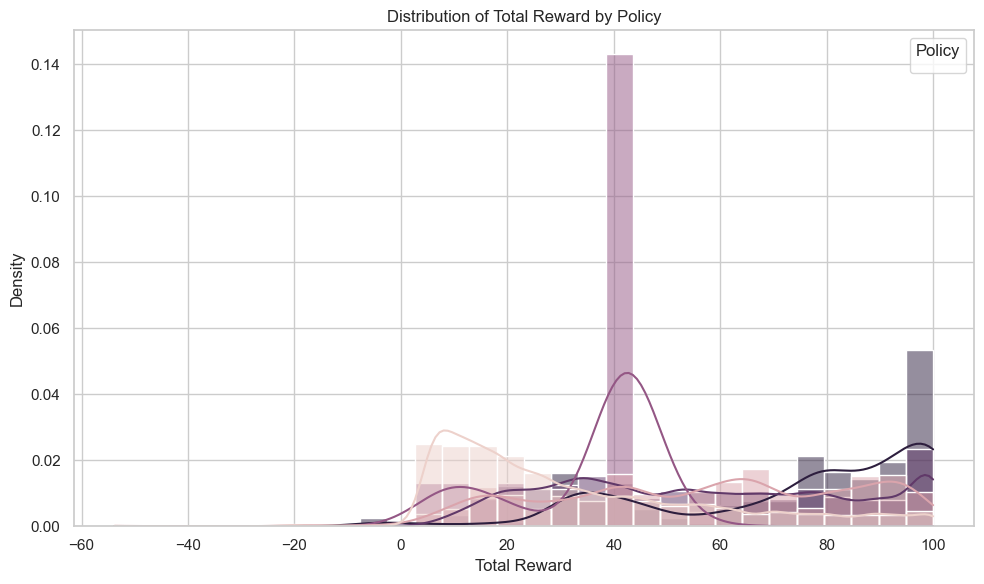

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the figure
plt.figure(figsize=(10, 6))

# Plot histogram of total_reward grouped by policy
sns.histplot(data=df, x="total_reward", hue="best_action", bins=30, kde=True, stat="density", common_norm=False)

plt.title("Distribution of Total Reward by Policy")
plt.xlabel("Total Reward")
plt.ylabel("Density")
plt.legend(title="Policy")
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
df

,subject_id,actions,behavior_probs,rewards,w_i,total_reward,gamma,best_action,true_action,rl_prob
0,401980707,4,0.245452,1.0,1.108482e-10,9.561792,0.99,0,4,0.000001
1,401980707,4,0.245452,1.0,1.108482e-10,9.561792,0.99,0,4,0.000001
2,401980707,4,0.245452,1.0,1.108482e-10,9.561792,0.99,0,4,0.000001
3,401980707,5,0.013059,1.0,1.108482e-10,9.561792,0.99,0,5,0.000001
4,401980707,5,0.013059,1.0,1.108482e-10,9.561792,0.99,0,5,0.000001
...,...,...,...,...,...,...,...,...,...,...
9870,31806382566,4,0.261993,1.0,3.816892e-12,42.464525,0.99,0,4,0.000001
9871,31806382566,4,0.261993,1.0,3.816892e-12,42.464525,0.99,0,4,0.000001
9872,31806382566,4,0.261993,1.0,3.816892e-12,42.464525,0.99,0,4,0.000001
9873,31806382566,4,0.261993,1.0,3.816892e-12,42.464525,0.99,0,4,0.000001


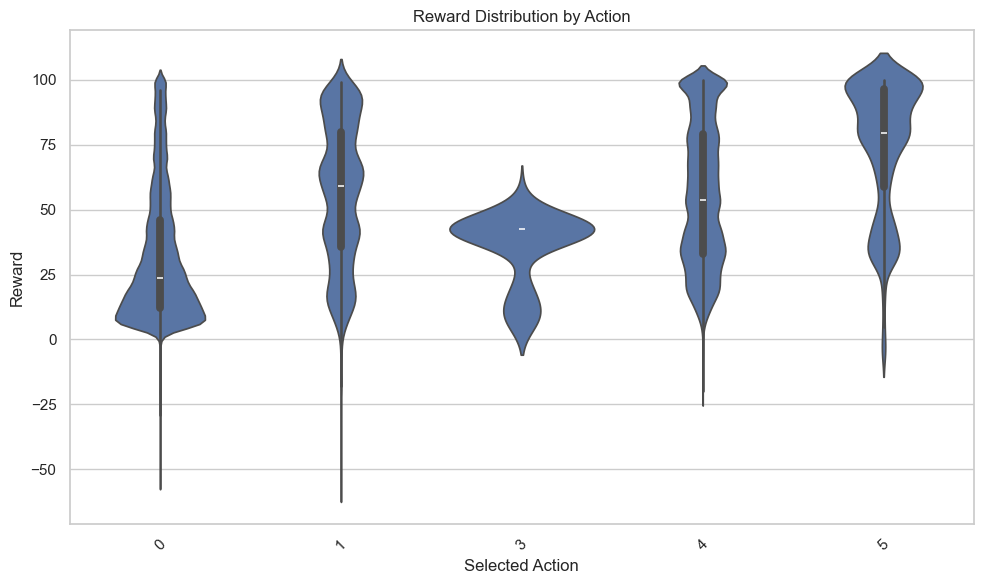

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="best_action", y="total_reward", inner="box")
plt.title("Reward Distribution by Action")
plt.xlabel("Selected Action")
plt.ylabel("Reward")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [28]:
df

,subject_id,actions,behavior_probs,rewards,w_i,total_reward,gamma,best_action,true_action,rl_prob
0,401980707,4,0.245452,1.0,1.108482e-10,9.561792,0.99,0,4,0.000001
1,401980707,4,0.245452,1.0,1.108482e-10,9.561792,0.99,0,4,0.000001
2,401980707,4,0.245452,1.0,1.108482e-10,9.561792,0.99,0,4,0.000001
3,401980707,5,0.013059,1.0,1.108482e-10,9.561792,0.99,0,5,0.000001
4,401980707,5,0.013059,1.0,1.108482e-10,9.561792,0.99,0,5,0.000001
...,...,...,...,...,...,...,...,...,...,...
9870,31806382566,4,0.261993,1.0,3.816892e-12,42.464525,0.99,0,4,0.000001
9871,31806382566,4,0.261993,1.0,3.816892e-12,42.464525,0.99,0,4,0.000001
9872,31806382566,4,0.261993,1.0,3.816892e-12,42.464525,0.99,0,4,0.000001
9873,31806382566,4,0.261993,1.0,3.816892e-12,42.464525,0.99,0,4,0.000001


/opt/anaconda3/envs/project/lib/python3.11/site-packages/seaborn/axisgrid.py:854: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)


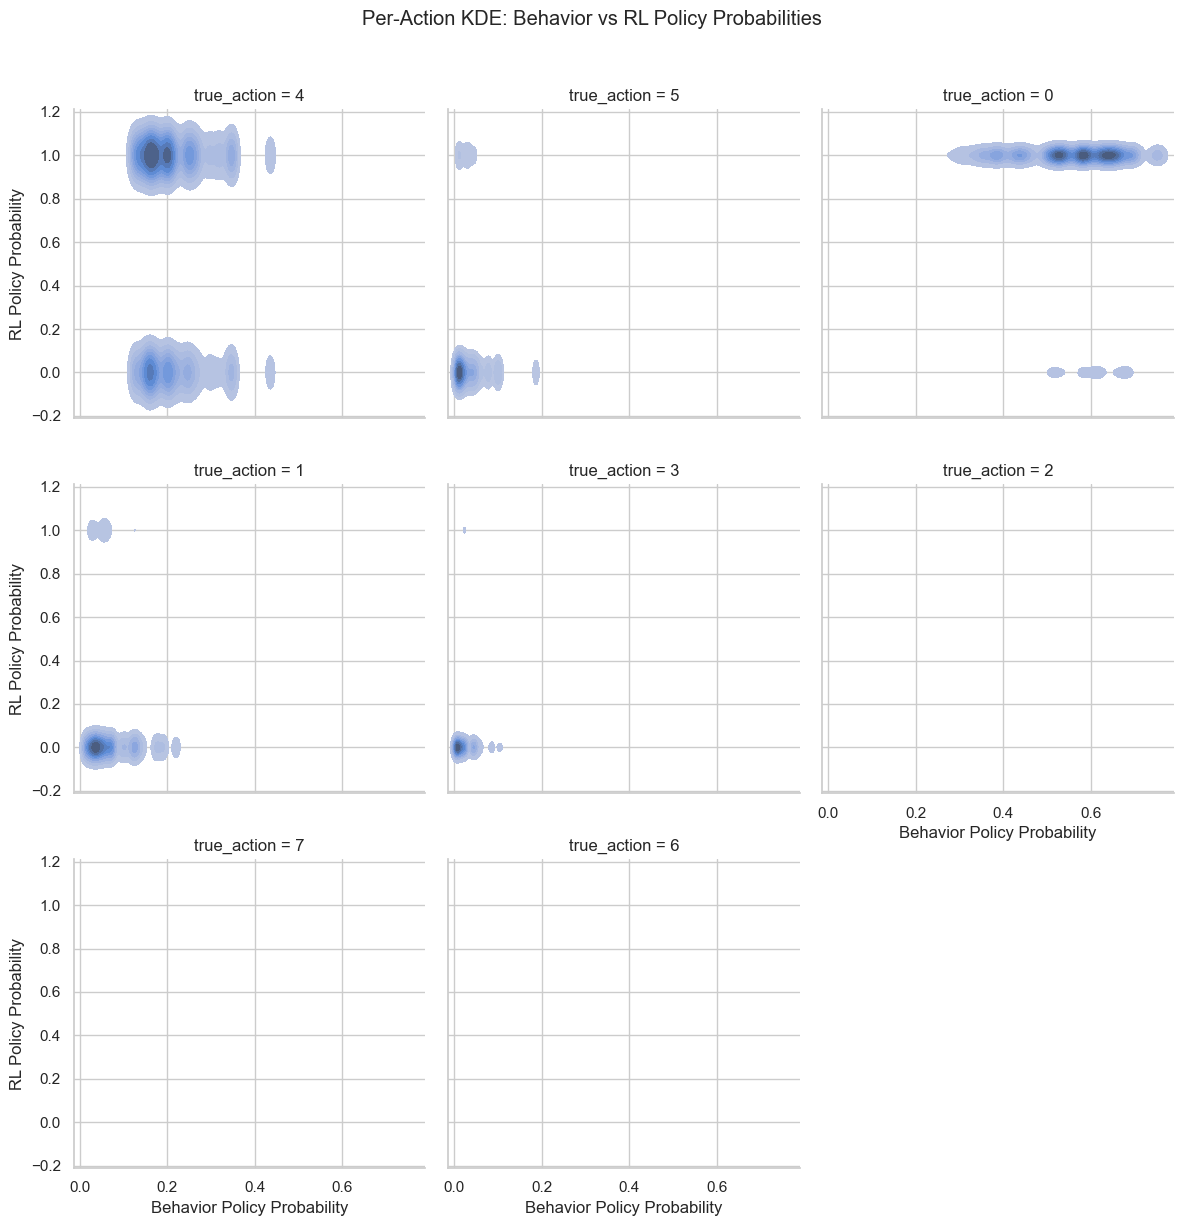

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd



# Remove invalid or missing values if any
df = df.dropna(subset=["behavior_probs", "rl_prob", "true_action"])

# Convert true_action to categorical if it's not already
df["true_action"] = df["true_action"].astype(str)

# Set up the plot
g = sns.FacetGrid(df, col="true_action", col_wrap=3, height=4, sharex=True, sharey=True)
g.map_dataframe(sns.kdeplot, x="behavior_probs", y="rl_prob", fill=True, thresh=0.05)
g.set_axis_labels("Behavior Policy Probability", "RL Policy Probability")
g.fig.suptitle("Per-Action KDE: Behavior vs RL Policy Probabilities", y=1.02)

plt.tight_layout()
plt.show()


/opt/anaconda3/envs/project/lib/python3.11/site-packages/seaborn/axisgrid.py:854: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)


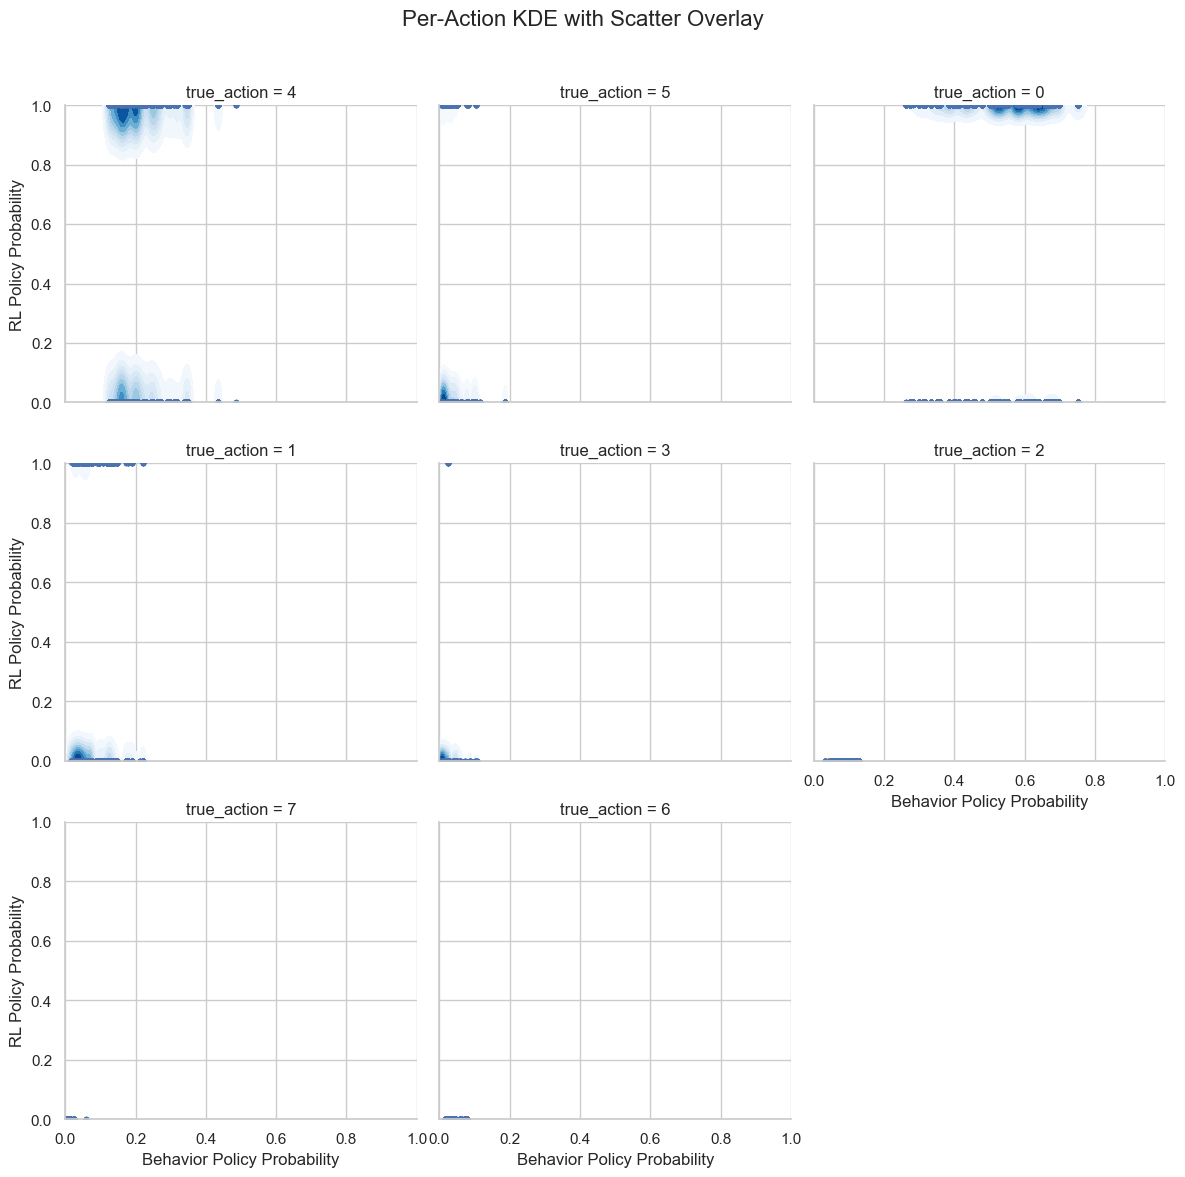

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame and g is your FacetGrid
def scatter_overlay(data, **kwargs):
    sns.scatterplot(
        data=data,
        x="behavior_probs",
        y="rl_prob",
        alpha=0.6,
        s=15,
        linewidth=0,
        **kwargs  # Let FacetGrid manage aesthetics
    )

g = sns.FacetGrid(
    df,
    col="true_action",
    col_wrap=3,
    sharex=True,
    sharey=True,
    height=4
)

g.map_dataframe(sns.kdeplot, x="behavior_probs", y="rl_prob", fill=True, thresh=0.05, cmap="Blues")
g.map_dataframe(scatter_overlay)  # No color arg here

g.set(xlim=(0, 1), ylim=(0, 1))
g.set_axis_labels("Behavior Policy Probability", "RL Policy Probability")
g.fig.suptitle("Per-Action KDE with Scatter Overlay", fontsize=16)
g.fig.subplots_adjust(top=0.9)

plt.show()



/opt/anaconda3/envs/project/lib/python3.11/site-packages/seaborn/axisgrid.py:854: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/project/lib/python3.11/site-packages/seaborn/axisgrid.py:854: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/project/lib/python3.11/site-packages/seaborn/axisgrid.py:854: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/project/lib/python3.11/site-packages/seaborn/axisgrid.py:854: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/opt/anaconda3/envs/project/lib/pyth

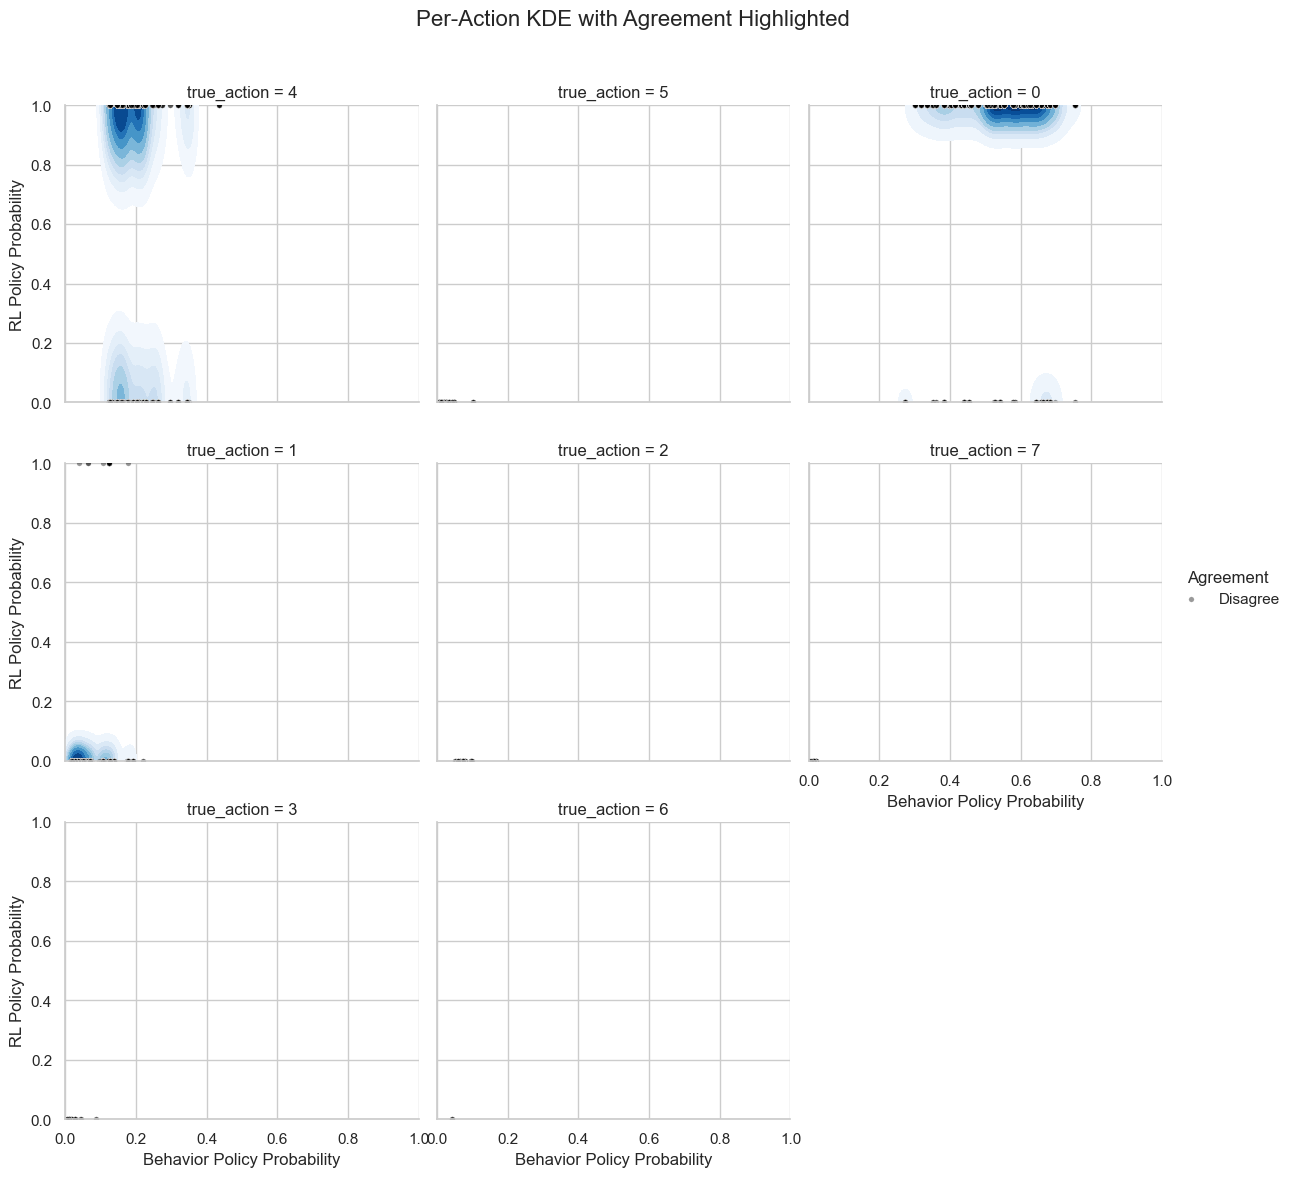

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Let's assume your DataFrame is called df and has the following columns:
# 'behavior_prob', 'rl_prob', 'true_action', 'best_action' (or any indicator of agreement)

# Create a new column indicating agreement
df["agreement"] = df["best_action"] == df["true_action"]  # or use df["rl_action"] == df["behavior_action"] if available

# Set up the grid
g = sns.FacetGrid(
    df,
    col="true_action",
    col_wrap=3,
    sharex=True,
    sharey=True,
    height=4
)

# KDE background
g.map_dataframe(
    sns.kdeplot,
    x="behavior_probs",
    y="rl_prob",
    fill=True,
    thresh=0.05,
    cmap="Blues"
)

# Overlay all scatter points
def scatter_overlay(data, **kwargs):
    # All points
    sns.scatterplot(
        data=data,
        x="behavior_probs",
        y="rl_prob",
        alpha=0.4,
        s=15,
        color="black",
        marker="o",
        label="Disagree"
    )
    
    # Agreement points
    sns.scatterplot(
        data=data[data["agreement"]],
        x="behavior_probs",
        y="rl_prob",
        alpha=0.8,
        s=30,
        color="red",
        marker="X",
        label="Agree"
    )

g.map_dataframe(scatter_overlay)

# Axis limits and titles
g.set(xlim=(0, 1), ylim=(0, 1))
g.set_axis_labels("Behavior Policy Probability", "RL Policy Probability")
g.fig.suptitle("Per-Action KDE with Agreement Highlighted", fontsize=16)
g.fig.subplots_adjust(top=0.9)

# Optional: Add legend (only once, not per facet)
handles, labels = g.axes[0].get_legend_handles_labels()
g.add_legend(title="Agreement", handles=handles[:2], labels=labels[:2])

plt.show()


/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_58036/4196000404.py:30: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_58036/4196000404.py:65: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 2
  g.ax_joint.legend(handles=handles, labels=["Disagree", "Agree"], title="Agreement")
/var/folders/75/wzxm1y795qn_1x0sm9jf2k_w0000gn/T/ipykernel_58036/4196000404.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.ax_joint.legend(handles=handles, labels=["Disagree", "Agree"], title="Agreement")


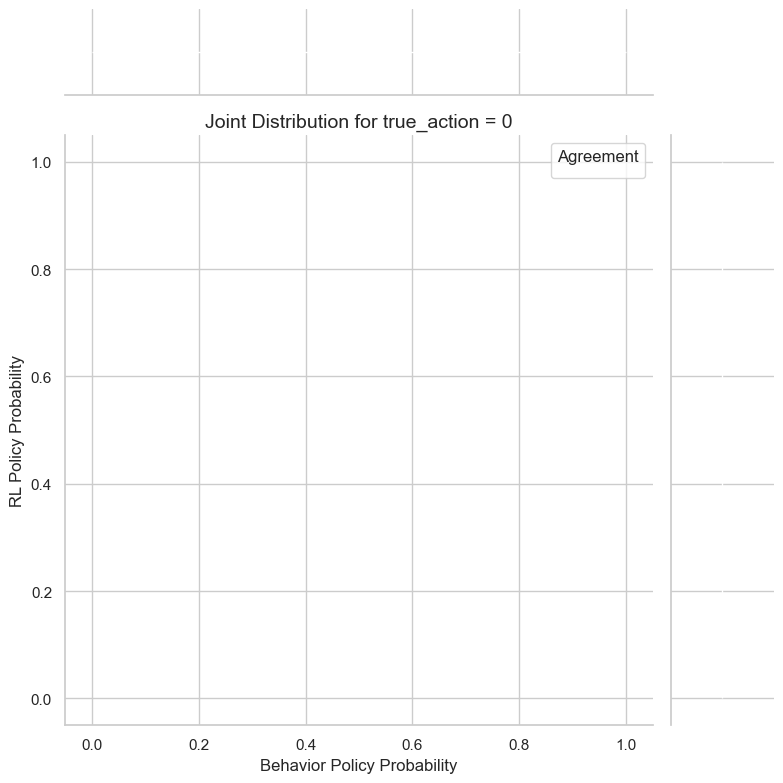

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Filter one action (say true_action == 0)
action_id = 0
df_action = df[df["true_action"] == action_id]

# Add agreement indicator
df_action["agreement"] = df_action["best_action"] == df_action["true_action"]

# Create JointGrid
g = sns.JointGrid(
    data=df_action,
    x="behavior_probs",
    y="rl_prob",
    space=0,
    height=8
)

# Main scatter or KDE
g.plot_joint(
    sns.kdeplot,
    fill=True,
    cmap="Blues",
    thresh=0.05
)

# Overlay scatter: highlight agreement points
sns.scatterplot(
    data=df_action,
    x="behavior_probs",
    y="rl_prob",
    hue="agreement",
    palette={True: "red", False: "black"},
    alpha=0.7,
    ax=g.ax_joint,
    marker="o"
)

# Marginal histograms
sns.histplot(
    data=df_action,
    x="behavior_probs",
    ax=g.ax_marg_x,
    kde=True,
    color="steelblue"
)

sns.histplot(
    data=df_action,
    y="rl_prob",
    ax=g.ax_marg_y,
    kde=True,
    color="steelblue"
)

# Set labels and title
g.ax_joint.set_xlabel("Behavior Policy Probability")
g.ax_joint.set_ylabel("RL Policy Probability")
g.ax_joint.set_title(f"Joint Distribution for true_action = {action_id}", fontsize=14)

# Legend
handles, labels = g.ax_joint.get_legend_handles_labels()
g.ax_joint.legend(handles=handles, labels=["Disagree", "Agree"], title="Agreement")

plt.tight_layout()
plt.show()


In [77]:
import d3rlpy
print(d3rlpy.__version__)

2.7.0
